# Near-Earth Object (NEO) Exploratory Data Analysis

**Author:** Anthony Mazza  
**Project:** NASA NEO Analytics Platform  

Transform structured asteroid data into scientific and operational insights.

## Dataset Information

| Field | Value |
|---|---|
| **Start Date** | `2024-01-01` |
| **End Date** | `2026-12-31` |
| **Total Days** | 1096 |
| **API Chunks** | 157 × 7-day windows |

To reproduce this dataset, run:
```
python -m src.run_pipeline --start-date 2024-01-01 --end-date 2026-12-31
```

In [181]:
%matplotlib inline
import sqlite3
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

import os
from dotenv import load_dotenv, find_dotenv

In [182]:
_dotenv_path = find_dotenv()
load_dotenv(_dotenv_path)


def _resolve_dotenv_dir() -> "Path":
    """Return the directory containing .env, falling back to a CWD walk-up."""
    if _dotenv_path:
        return Path(_dotenv_path).parent
    here = Path.cwd()
    for _ in range(8):
        if (here / ".env").exists():
            return here
        parent = here.parent
        if parent == here:
            break
        here = parent
    return Path.cwd()


def get_db_path() -> Path:
    env_path = os.getenv("DATABASE_PATH")
    if not env_path:
        raise EnvironmentError(
            "DATABASE_PATH is not set. Add it to your .env file, e.g.:\n"
            "  DATABASE_PATH=data/database/neows.db"
        )
    p = Path(env_path)
    if not p.is_absolute():
        p = _resolve_dotenv_dir() / p
    return p


DB_PATH = get_db_path()

if not DB_PATH.exists():
    raise FileNotFoundError(f"Database not found: {DB_PATH}")

conn = sqlite3.connect(DB_PATH)
print(f"Connected to: {DB_PATH}")


Connected to: c:\Users\arcen\git\neo-analytics-platform\data\database\neows.db


In [183]:
asteroids_df = pd.read_sql_query("SELECT * FROM asteroids", conn)
close_approaches_df = pd.read_sql_query("SELECT * FROM close_approaches", conn)
orbital_parameters_df = pd.read_sql_query("SELECT * FROM orbital_parameters", conn)

print(f"asteroids:          {len(asteroids_df):>4} rows, {asteroids_df.shape[1]} columns")
print(f"close_approaches:   {len(close_approaches_df):>4} rows, {close_approaches_df.shape[1]} columns")
print(f"orbital_parameters: {len(orbital_parameters_df):>4} rows, {orbital_parameters_df.shape[1]} columns")

asteroids:          4084 rows, 6 columns
close_approaches:   5551 rows, 6 columns
orbital_parameters: 4084 rows, 26 columns


## Missing Value Assessment

In [184]:
def missing_report(df):
    null_counts = df.isnull().sum()
    missing_pct = (null_counts / len(df) * 100).round(2)
    return pd.DataFrame({
        "null_count": null_counts,
        "missing_%": missing_pct
    }).sort_values("null_count", ascending=False)

print("asteroids")
display(missing_report(asteroids_df))

print("close_approaches")
display(missing_report(close_approaches_df))

print("orbital_parameters")
display(missing_report(orbital_parameters_df))

asteroids


,null_count,missing_%
asteroid_id,0,0.0
name,0,0.0
absolute_magnitude_h,0,0.0
estimated_diameter_min_km,0,0.0
estimated_diameter_max_km,0,0.0
is_potentially_hazardous,0,0.0


close_approaches


,null_count,missing_%
close_approach_id,0,0.0
asteroid_id,0,0.0
close_approach_date,0,0.0
relative_velocity_kps,0,0.0
miss_distance_km,0,0.0
orbiting_body,0,0.0


orbital_parameters


,null_count,missing_%
data_arc_in_days,12,0.29
asteroid_id,0,0.00
orbit_id,0,0.00
orbit_determination_date,0,0.00
first_observation_date,0,0.00
last_observation_date,0,0.00
observations_used,0,0.00
orbit_uncertainty,0,0.00
minimum_orbit_intersection,0,0.00
jupiter_tisserand_invariant,0,0.00


## Data Type Validation

In [185]:
print("asteroids")
display(asteroids_df.dtypes.to_frame("dtype"))

print("close_approaches")
display(close_approaches_df.dtypes.to_frame("dtype"))

print("orbital_parameters")
display(orbital_parameters_df.dtypes.to_frame("dtype"))

asteroids


,dtype
asteroid_id,object
name,object
absolute_magnitude_h,float64
estimated_diameter_min_km,float64
estimated_diameter_max_km,float64
is_potentially_hazardous,int64


close_approaches


,dtype
close_approach_id,int64
asteroid_id,object
close_approach_date,object
relative_velocity_kps,float64
miss_distance_km,float64
orbiting_body,object


orbital_parameters


,dtype
asteroid_id,object
orbit_id,object
orbit_determination_date,object
first_observation_date,object
last_observation_date,object
data_arc_in_days,float64
observations_used,int64
orbit_uncertainty,object
minimum_orbit_intersection,float64
jupiter_tisserand_invariant,float64


In [186]:
# Fix boolean
asteroids_df["is_potentially_hazardous"] = asteroids_df["is_potentially_hazardous"].astype(bool)

# Fix date columns
close_approaches_df["close_approach_date"] = pd.to_datetime(close_approaches_df["close_approach_date"])

orbital_parameters_df["orbit_determination_date"] = pd.to_datetime(orbital_parameters_df["orbit_determination_date"])
orbital_parameters_df["first_observation_date"] = pd.to_datetime(orbital_parameters_df["first_observation_date"])
orbital_parameters_df["last_observation_date"] = pd.to_datetime(orbital_parameters_df["last_observation_date"])

print("asteroids")
display(asteroids_df.dtypes.to_frame("dtype"))

print("close_approaches")
display(close_approaches_df.dtypes.to_frame("dtype"))

print("orbital_parameters")
display(orbital_parameters_df.dtypes.to_frame("dtype"))

asteroids


,dtype
asteroid_id,object
name,object
absolute_magnitude_h,float64
estimated_diameter_min_km,float64
estimated_diameter_max_km,float64
is_potentially_hazardous,bool


close_approaches


,dtype
close_approach_id,int64
asteroid_id,object
close_approach_date,datetime64[ns]
relative_velocity_kps,float64
miss_distance_km,float64
orbiting_body,object


orbital_parameters


,dtype
asteroid_id,object
orbit_id,object
orbit_determination_date,datetime64[ns]
first_observation_date,datetime64[ns]
last_observation_date,datetime64[ns]
data_arc_in_days,float64
observations_used,int64
orbit_uncertainty,object
minimum_orbit_intersection,float64
jupiter_tisserand_invariant,float64


## Data Quality Assessment

In [187]:
print("=== Duplicate Records ===\n")

ast_dupes = asteroids_df.duplicated(subset="asteroid_id").sum()
ca_dupes = close_approaches_df.duplicated(subset=["asteroid_id", "close_approach_date"]).sum()
op_dupes = orbital_parameters_df.duplicated(subset="asteroid_id").sum()

print(f"  asteroids          (asteroid_id):                {ast_dupes} duplicates")
print(f"  close_approaches   (asteroid_id + date):         {ca_dupes} duplicates")
print(f"  orbital_parameters (asteroid_id):                {op_dupes} duplicates")

=== Duplicate Records ===

  asteroids          (asteroid_id):                0 duplicates
  close_approaches   (asteroid_id + date):         0 duplicates
  orbital_parameters (asteroid_id):                0 duplicates


In [188]:
print("=== Impossible Values ===\n")

checks = {
    "absolute_magnitude_h < 0":      (asteroids_df["absolute_magnitude_h"] < 0).sum(),
    "estimated_diameter_min_km < 0": (asteroids_df["estimated_diameter_min_km"] < 0).sum(),
    "estimated_diameter_max_km < 0": (asteroids_df["estimated_diameter_max_km"] < 0).sum(),
    "diameter_min > diameter_max": (
        asteroids_df["estimated_diameter_min_km"]
        > asteroids_df["estimated_diameter_max_km"]
    ).sum(),
    "relative_velocity_kps < 0":  (close_approaches_df["relative_velocity_kps"] < 0).sum(),
    "miss_distance_km < 0":       (close_approaches_df["miss_distance_km"] < 0).sum(),
    "eccentricity < 0 or > 1": (
        (orbital_parameters_df["eccentricity"] < 0).sum()
        | (orbital_parameters_df["eccentricity"] > 1).sum()
    ),
    "inclination < 0 or > 180": (
        (orbital_parameters_df["inclination"] < 0)
        | (orbital_parameters_df["inclination"] > 180)
    ).sum(),
    "orbital_period < 0": (orbital_parameters_df["orbital_period"] < 0).sum(),
}

for label, count in checks.items():
    status = "ISSUE" if count > 0 else "OK"
    print(f"  [{status}] {label}: {count} records")

=== Impossible Values ===

  [OK] absolute_magnitude_h < 0: 0 records
  [OK] estimated_diameter_min_km < 0: 0 records
  [OK] estimated_diameter_max_km < 0: 0 records
  [OK] diameter_min > diameter_max: 0 records
  [OK] relative_velocity_kps < 0: 0 records
  [OK] miss_distance_km < 0: 0 records
  [OK] eccentricity < 0 or > 1: 0 records
  [OK] inclination < 0 or > 180: 0 records
  [OK] orbital_period < 0: 0 records


In [189]:
print("=== Suspicious Outliers (3x IQR) ===\n")

def count_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return ((series < Q1 - 3 * IQR) | (series > Q3 + 3 * IQR)).sum()

outlier_checks = {
    "asteroids": {
        "df": asteroids_df,
        "cols": ["absolute_magnitude_h", "estimated_diameter_min_km", "estimated_diameter_max_km"],
    },
    "close_approaches": {
        "df": close_approaches_df,
        "cols": ["relative_velocity_kps", "miss_distance_km"],
    },
    "orbital_parameters": {
        "df": orbital_parameters_df,
        "cols": ["eccentricity", "inclination", "orbital_period", "semi_major_axis"],
    },
}

for table, info in outlier_checks.items():
    print(f"  {table}")
    for col in info["cols"]:
        count = count_outliers(info["df"][col])
        status = "OUTLIER" if count > 0 else "OK"
        print(f"    [{status}] {col}: {count} extreme values")
    print()

=== Suspicious Outliers (3x IQR) ===

  asteroids
    [OK] absolute_magnitude_h: 0 extreme values
    [OUTLIER] estimated_diameter_min_km: 128 extreme values
    [OUTLIER] estimated_diameter_max_km: 128 extreme values

  close_approaches
    [OUTLIER] relative_velocity_kps: 1 extreme values
    [OK] miss_distance_km: 0 extreme values

  orbital_parameters
    [OK] eccentricity: 0 extreme values
    [OUTLIER] inclination: 14 extreme values
    [OUTLIER] orbital_period: 21 extreme values
    [OUTLIER] semi_major_axis: 3 extreme values



### Summary

**Duplicates:** No duplicate records found in any table (checked by `asteroid_id` in `asteroids` and `orbital_parameters`; by `asteroid_id` + `close_approach_date` in `close_approaches`).

**Impossible Values:** All 9 domain checks passed — no negative magnitudes, diameters, velocities, or distances; no inverted diameter bounds; eccentricity, inclination, and orbital period all within valid ranges.

**Outliers (3× IQR):**

| Table | Column | Extreme Values |
|---|---|---|
| `asteroids` | `estimated_diameter_min_km` | 128 |
| `asteroids` | `estimated_diameter_max_km` | 128 |
| `close_approaches` | `relative_velocity_kps` | 1 |
| `orbital_parameters` | `inclination` | 14 |
| `orbital_parameters` | `orbital_period` | 21 |
| `orbital_parameters` | `semi_major_axis` | 3 |

These 295 flagged values are statistically extreme but not physically impossible — they likely represent genuinely large or orbitally unusual asteroids. No records were removed; they are noted for consideration during analysis.

## Asteroid Size Analysis

### 4.2.1 Diameter Distribution Statistics

In [190]:
diameter_cols = ["estimated_diameter_min_km", "estimated_diameter_max_km"]

stats = (
    asteroids_df[diameter_cols]
    .describe()
    .rename(index={"25%": "Q1", "50%": "median", "75%": "Q3"})
)

display(stats)

,estimated_diameter_min_km,estimated_diameter_max_km
count,4084.000000,4084.000000
mean,0.132848,0.297058
std,0.401593,0.897988
min,0.000922,0.002061
Q1,0.023150,0.051765
median,0.060891,0.136157
Q3,0.157237,0.351593
max,22.108281,49.435619


#### Summary

All 4,084 asteroids have diameter estimates. The distribution is **right-skewed** — the mean exceeds the median for both columns, and the maximum is well above Q3.

| Statistic | Min Diameter (km) | Max Diameter (km) |
|---|---|---|
| min | 0.000922 | 0.002061 |
| Q1 | 0.023150 | 0.051765 |
| median | 0.060891 | 0.136157 |
| Q3 | 0.157237 | 0.351593 |
| max | 22.108281 | 49.435619 |
| mean | 0.132848 | 0.297058 |
| std | 0.401593 | 0.897988 |

The typical NEO in this dataset (median) has an estimated diameter of roughly **61–136 meters** — smaller than a city block. The largest object (433 Eros) reaches ~49.4 km at maximum estimate, roughly 141× above Q3, confirming the large number of diameter outliers flagged in 4.1.4.

### 4.2.2 Size Histogram

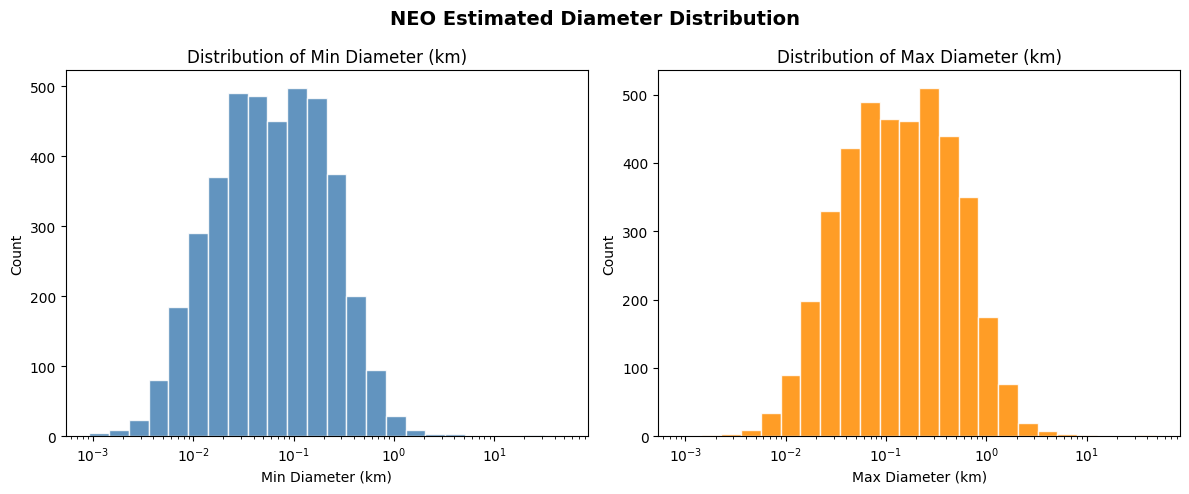

In [191]:
bins = np.logspace(
    np.log10(asteroids_df["estimated_diameter_min_km"].min()),
    np.log10(asteroids_df["estimated_diameter_max_km"].max()),
    25,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, label, color in zip(
    axes,
    ["estimated_diameter_min_km", "estimated_diameter_max_km"],
    ["Min Diameter (km)", "Max Diameter (km)"],
    ["steelblue", "darkorange"],
):
    ax.hist(asteroids_df[col], bins=bins, color=color, edgecolor="white", alpha=0.85)
    ax.set_xscale("log")
    ax.set_xlabel(label)
    ax.set_ylabel("Count")
    ax.set_title(f"Distribution of {label}")

fig.suptitle("NEO Estimated Diameter Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

#### Summary

Both histograms use a **logarithmic x-axis** to accommodate the wide spread of the diameter distribution — on a linear scale, the tail driven by a few large asteroids would compress the bulk of the data into an unreadable cluster near zero.

With 4,084 asteroids, the distribution takes on a roughly **log-normal shape** — approximately bell-shaped on the log scale, peaking in the 0.03–0.2 km range. The right tail extends to ~22.1 km (min) and ~49.4 km (max), driven by a small number of notably large objects including 433 Eros at the top of the ranking. The min and max diameter plots share the same overall shape, as expected — max is a scaled-up version of min based on NASA's size estimation model.

### 4.2.3 Identify Largest Objects

In [192]:
top20 = (
    asteroids_df[["asteroid_id", "name", "estimated_diameter_min_km", "estimated_diameter_max_km"]]
    .sort_values("estimated_diameter_max_km", ascending=False)
    .head(20)
    .reset_index(drop=True)
)
top20.index += 1
top20.index.name = "rank"

display(top20)

,asteroid_id,name,estimated_diameter_min_km,estimated_diameter_max_km
rank,,,,
1,2000433,433 Eros (A898 PA),22.108281,49.435619
2,2000887,887 Alinda (A918 AA),4.576727,10.233872
3,2001685,1685 Toro (1948 OA),3.737274,8.356799
4,2066146,66146 (1998 TU3),3.569069,7.980681
5,2138205,138205 (2000 EZ148),2.561858,5.728488
6,2001620,1620 Geographos (1951 RA),2.347226,5.248558
7,2005660,5660 (1974 MA),2.231285,4.989304
8,2001943,1943 Anteros (1973 EC),1.961349,4.385711
9,2066008,66008 (1998 QH2),1.732028,3.872933


### 4.2.4 Interpret Findings

**Skewness**

The diameter distribution is right-skewed. The mean (~0.133 km min / ~0.297 km max) is more than 2× the median (~0.061 km min / ~0.136 km max), signaling that a small number of large asteroids pull the average upward. On a log scale (4.2.2), the distribution appears roughly log-normal — most objects cluster in a well-defined central range, with a long right tail.

**Rarity of Large Objects**

Large NEOs are uncommon in this dataset. Q3 sits at 0.352 km (max diameter), yet the largest object — 433 Eros — reaches ~49.4 km, roughly 141× above the third quartile. The top 20 list (4.2.3) shows that all 20 largest asteroids exceed 1 km in maximum estimated diameter, representing less than 0.5% of the 4,084-asteroid dataset. This is consistent with the known real-world pattern: small asteroids vastly outnumber large ones.

**Implications**

- **Hazard assessment:** Larger asteroids carry significantly higher impact energy. Although rare, km-scale NEOs making close approaches warrant close monitoring regardless of their statistical infrequency.
- **Statistical analysis:** The mean is not representative of a typical asteroid in this dataset; the median is a more appropriate central measure given the skew.
- **Modeling:** Any size-dependent analysis (e.g., correlating diameter with miss distance or velocity) should account for this skew, either through log-transformation or by treating the largest objects as a distinct subgroup.

## Velocity Analysis

### 4.3.1 Relative Velocity Distribution

In [193]:
velocity_stats = (
    close_approaches_df["relative_velocity_kps"]
    .agg(["mean", "median", "var"])
    .rename({"var": "variance"})
    .to_frame("relative_velocity_kps")
)

display(velocity_stats)

,relative_velocity_kps
mean,13.864824
median,13.056946
variance,49.193562


#### Summary

| Statistic | relative_velocity_kps |
|---|---|
| mean | 13.864824 |
| median | 13.056946 |
| variance | 49.193562 |

The mean (~13.9 km/s) sits slightly above the median (~13.1 km/s), indicating a mild right skew — a small number of faster-moving approaches pull the average up. The standard deviation (~7.0 km/s, √49.2) is substantial relative to the mean, reflecting genuine spread in approach velocities across the dataset rather than a tightly clustered population.

### 4.3.2 Visualize Velocity Distribution

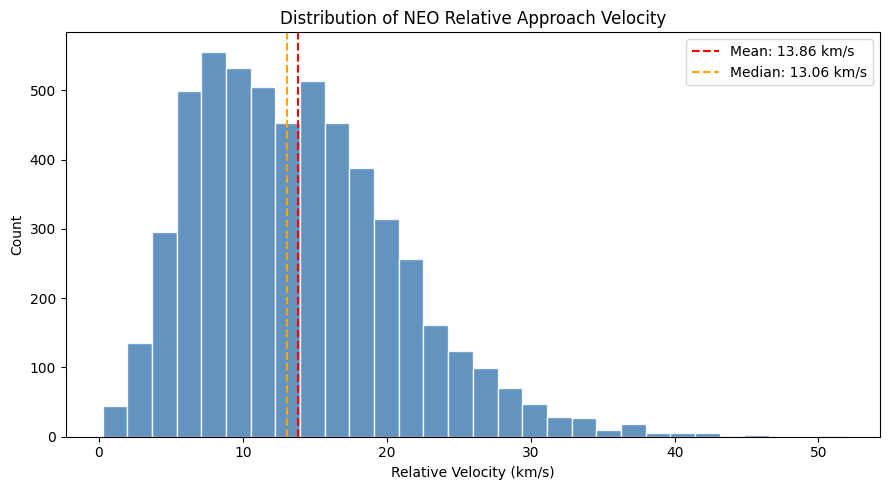

In [194]:
mean_vel = close_approaches_df["relative_velocity_kps"].mean()
median_vel = close_approaches_df["relative_velocity_kps"].median()

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    close_approaches_df["relative_velocity_kps"],
    bins=30,
    color="steelblue",
    edgecolor="white",
    alpha=0.85,
)

ax.axvline(mean_vel, color="red", linestyle="--", linewidth=1.5, label=f"Mean: {mean_vel:.2f} km/s")
ax.axvline(median_vel, color="orange", linestyle="--", linewidth=1.5, label=f"Median: {median_vel:.2f} km/s")

ax.set_xlabel("Relative Velocity (km/s)")
ax.set_ylabel("Count")
ax.set_title("Distribution of NEO Relative Approach Velocity")
ax.legend()

plt.tight_layout()
plt.show()

#### Summary

The histogram confirms the mild right skew noted in 4.3.1. The bulk of close approaches fall between **5–20 km/s**, with the distribution peaking around 8–10 km/s before tapering into a right tail that extends to ~45 km/s. The mean (13.86 km/s, red) and median (13.06 km/s, orange) are close together and both sit near the center of the main cluster — the small gap between them reflects the modest pull of the faster-moving tail. No approaches were found at near-zero velocity, consistent with the impossible-values check in 4.1.4.

### 4.3.3 Identify Fastest Recorded Approaches

In [195]:
top20_velocity = (
    close_approaches_df
    .merge(asteroids_df[["asteroid_id", "name"]], on="asteroid_id", how="left")
    [["name", "asteroid_id", "close_approach_date", "relative_velocity_kps", "miss_distance_km"]]
    .sort_values("relative_velocity_kps", ascending=False)
    .head(20)
    .reset_index(drop=True)
)
top20_velocity.index += 1
top20_velocity.index.name = "rank"

display(top20_velocity)

,name,asteroid_id,close_approach_date,relative_velocity_kps,miss_distance_km
rank,,,,,
1,504181 (2006 TC),2504181,2025-10-12,51.704413,7.471847e+07
2,(2013 LC7),3639550,2026-05-31,45.517616,6.704966e+07
3,(2018 GG5),3803884,2024-02-18,44.866916,4.569786e+07
4,(2017 WP28),3790060,2024-01-13,43.966629,7.405282e+07
5,(2008 QB),3425295,2024-08-02,42.871224,7.438070e+07
6,(2011 WD39),3588900,2024-06-11,42.088999,7.071916e+07
7,(2008 JN),3409988,2026-04-24,41.977651,6.508094e+07
8,(2021 CQ3),54111253,2025-03-12,41.828617,6.944754e+07
9,(2018 YC2),3837511,2026-12-28,41.510474,2.548631e+07


#### Analysis

The top 20 fastest approaches span all three years of the dataset (**2024–2026**), with no single year dominating. Velocities range from ~38.0 to 51.7 km/s — roughly 3–4× the dataset mean of 13.86 km/s — confirming these represent the far right tail of the distribution seen in 4.3.2.

The fastest recorded approach is **504181 (2006 TC)** at **51.70 km/s** on 2025-10-12. Its miss distance (~7.47×10⁷ km) is large, placing it near the outer edge of the close-approach window. Previously the record holder, **(2013 LC7)** at 45.52 km/s on 2026-05-31, now ranks second. All 20 entries have miss distances in the tens of millions of km (ranging from ~1.6×10⁷ to ~7.5×10⁷ km), indicating that high velocity alone does not correlate with proximity in this dataset.

No catalog alias duplicate pairs are present in the new top-20 list, in contrast to the earlier 6-month dataset.

### 4.3.4 Interpret Velocity Findings

**Spread**

Relative approach velocities span a wide range across the dataset, with a standard deviation of ~7.0 km/s against a mean of ~13.9 km/s. This high coefficient of variation (~50%) reflects genuine diversity in the orbital geometries of tracked NEOs rather than measurement noise — different asteroids cross Earth's orbit at fundamentally different speeds depending on their eccentricity, inclination, and the geometry of the encounter. The interquartile range captures a moderately broad central population, while the histogram (4.3.2) shows a smooth right tail with no distinct secondary clusters.

**Extreme Values**

The fastest recorded approach — **504181 (2006 TC)** at **51.70 km/s** on 2025-10-12 — is more than 3.7× the dataset mean and represents the outermost point of the right tail. The top 20 fastest approaches (4.3.3) all exceed 38 km/s and span all three years of the dataset (2024–2026), with no catalog alias duplicate pairs identified in this group.

**Possible Significance**

- **Hazard context:** Velocity is a key factor in impact energy (kinetic energy scales with v²), so the fastest-moving objects carry disproportionately higher potential impact energy even at smaller sizes. A 52 km/s approach delivers roughly 14× the kinetic energy of a 14 km/s approach for the same mass.
- **Miss distance independence:** High velocity does not predict a closer pass — the top 20 fastest approaches all had large miss distances (tens of millions of km). Hazard assessment requires evaluating velocity and miss distance together, not either alone.
- **Orbital interpretation:** Extreme velocities are consistent with high-inclination or high-eccentricity orbits. Cross-referencing with `orbital_parameters` (e.g., `inclination`, `eccentricity`) could confirm this in later analysis.

## Close Approach Analysis

### 4.4.1 Analyze Miss Distance Distribution

In [196]:
miss_distance_stats = (
    close_approaches_df["miss_distance_km"]
    .agg(["median", "min", "max"])
    .to_frame("miss_distance_km")
)

display(miss_distance_stats)

,miss_distance_km
median,3.958455e+07
min,1.366105e+05
max,7.479169e+07


#### Summary

| Statistic | miss_distance_km |
|---|---|
| min | 1.366105e+05 (~136,611 km) |
| median | 3.958455e+07 (~39.6 million km) |
| max | 7.479169e+07 (~74.8 million km) |

The most striking figure is the **minimum: ~136,611 km** — less than 36% of the Moon's average distance (~384,400 km). This represents a genuinely exceptional close encounter by planetary standards. The median of ~39.6 million km indicates that most approaches pass at comfortable distances, while the max of ~74.8 million km sits near the outer edge of what NASA classifies as a close approach. The wide spread between min and max (~548× difference) suggests the distribution will be broad and likely right-skewed.

### 4.4.2 Visualize Miss Distance Distribution

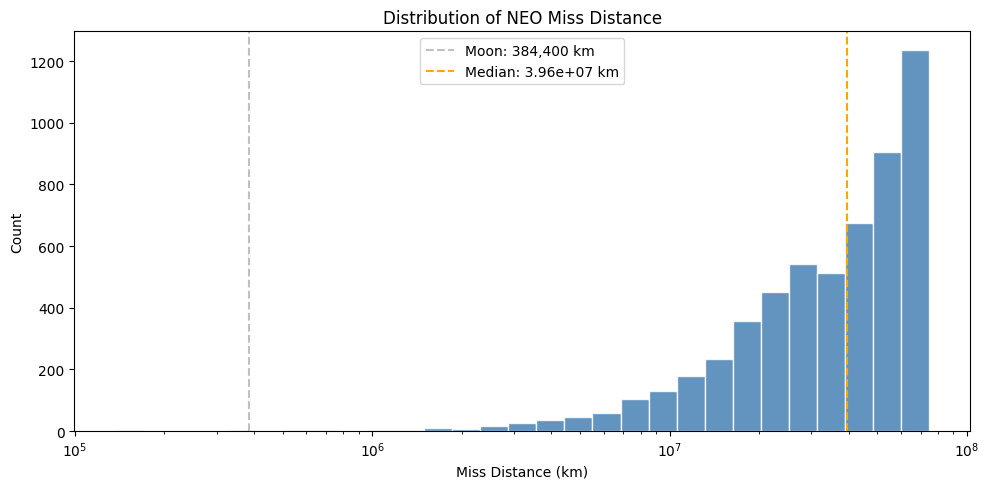

In [197]:
MOON_DISTANCE_KM = 384_400

bins = np.logspace(
    np.log10(close_approaches_df["miss_distance_km"].min()),
    np.log10(close_approaches_df["miss_distance_km"].max()),
    30,
)

median_dist = close_approaches_df["miss_distance_km"].median()

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    close_approaches_df["miss_distance_km"],
    bins=bins,
    color="steelblue",
    edgecolor="white",
    alpha=0.85,
)

ax.axvline(MOON_DISTANCE_KM, color="silver", linestyle="--", linewidth=1.5, label=f"Moon: {MOON_DISTANCE_KM:,} km")
ax.axvline(median_dist, color="orange", linestyle="--", linewidth=1.5, label=f"Median: {median_dist:.2e} km")

ax.set_xscale("log")
ax.set_xlabel("Miss Distance (km)")
ax.set_ylabel("Count")
ax.set_title("Distribution of NEO Miss Distance")
ax.legend()

plt.tight_layout()
plt.show()

#### Summary

The log-scale histogram reveals a distribution that rises steadily toward larger distances — the opposite shape from diameter and velocity. The vast majority of approaches in this dataset occur at distances of **10 million km or more**, with counts increasing as distance increases toward the dataset maximum of ~74.8 million km.

The Moon reference line (gray, ~384,400 km) sits at the far left edge of the chart, with only a handful of approaches falling within lunar distance — visually confirming that sub-lunar encounters are rare but present. The median (~3.96×10⁷ km, orange) falls roughly in the middle of the log range but to the left of where most approaches cluster, reflecting the rightward lean of the distribution.

This pattern is consistent with how NASA's NeoWs API captures close approaches: the pool of possible encounters grows with distance (more orbital paths intersect at larger radii), so larger miss distances are naturally more common within the tracking window.

### 4.4.3 Identify Closest Approaches

In [198]:
merge_cols = ["asteroid_id", "name", "estimated_diameter_max_km", "is_potentially_hazardous"]
select_cols = [
    "name", "asteroid_id", "close_approach_date", "miss_distance_km",
    "relative_velocity_kps", "estimated_diameter_max_km", "is_potentially_hazardous",
]

top20_closest = (
    close_approaches_df
    .merge(asteroids_df[merge_cols], on="asteroid_id", how="left")
    [select_cols]
    .sort_values("miss_distance_km", ascending=True)
    .head(20)
    .reset_index(drop=True)
)
top20_closest.index += 1
top20_closest.index.name = "rank"

display(top20_closest)

,name,asteroid_id,close_approach_date,miss_distance_km,relative_velocity_kps,estimated_diameter_max_km,is_potentially_hazardous
rank,,,,,,,
1,(2025 US6),54554706,2025-11-13,1.366105e+05,2.077811,0.003736,False
2,(2025 US6),54554706,2025-09-10,1.508417e+05,1.943865,0.003736,False
3,(2025 US6),54554706,2025-10-28,1.510885e+05,1.950538,0.003736,False
4,(2025 US6),54554706,2025-10-12,1.544241e+05,1.922091,0.003736,False
5,(2025 US6),54554706,2025-12-02,1.594955e+05,1.892867,0.003736,False
6,(2025 US6),54554706,2025-09-26,1.607258e+05,1.869598,0.003736,False
7,(2013 GM3),3634154,2026-04-14,2.605281e+05,7.409508,0.032662,False
8,(2024 JV8),54441093,2024-02-23,3.642427e+05,1.484077,0.033794,False
9,(2025 US6),54554706,2025-09-03,3.811252e+05,1.563750,0.003736,False


#### Analysis

The closest approach in the dataset belongs to **(2025 US6)** on 2025-11-13, passing at **~136,611 km** — less than 36% of the Moon's average distance (~384,400 km). This same asteroid dominates the top 10, accounting for 8 of the 10 closest entries (ranks 1–6, 9, and 10) across multiple passes in 2025. All 8 of its appearances represent sub-lunar encounters, which is physically explained by (2025 US6)'s tiny size (~3.7 m max diameter estimated) — its orbit brings it through Earth's immediate neighbourhood repeatedly during this period. Because it is so small, it poses no meaningful risk.

The previously highest-ranked approach, **(2013 GM3)** at ~260,528 km on 2026-04-14, now sits at **rank 7**. **(2024 JV8)** appears at ranks 8 and 11 with two separate passes. The top 10 entries are all within lunar distance, making this a notably close set of encounters in the full 2024–2026 dataset.

**No potentially hazardous asteroids appear in the top 20 closest approaches.** This is consistent with PHO classification being based on minimum orbit intersection distance (MOID) across the full orbital lifetime — not on the closest observed pass in any given window. PHO orbits may still come close to Earth's path, but the timing of their closest passes within this dataset does not place them in the top 20.

One catalog alias pair is visible:

- **Ranks 12 & 13** — `(2026 EK1)` and `(2015 EX)` share the same date (2026-03-08) with nearly identical miss distances (~562,176 km vs ~562,320 km) and velocities (~10.68 km/s), strongly suggesting the same physical object recorded under two designations.

Approaches in the top 20 span all three years of the dataset (2024–2026). Consistent with the finding from 4.3.4 that proximity and velocity are independent, the closest encounters are relatively slow — mostly 1–10 km/s, well below the dataset mean of ~13.9 km/s — with one extreme outlier at rank 10 ((2025 US6) on 2025-11-22) recording only 0.26 km/s, indicating an almost tangential pass.

### 4.4.4 Analyze Approach Frequency

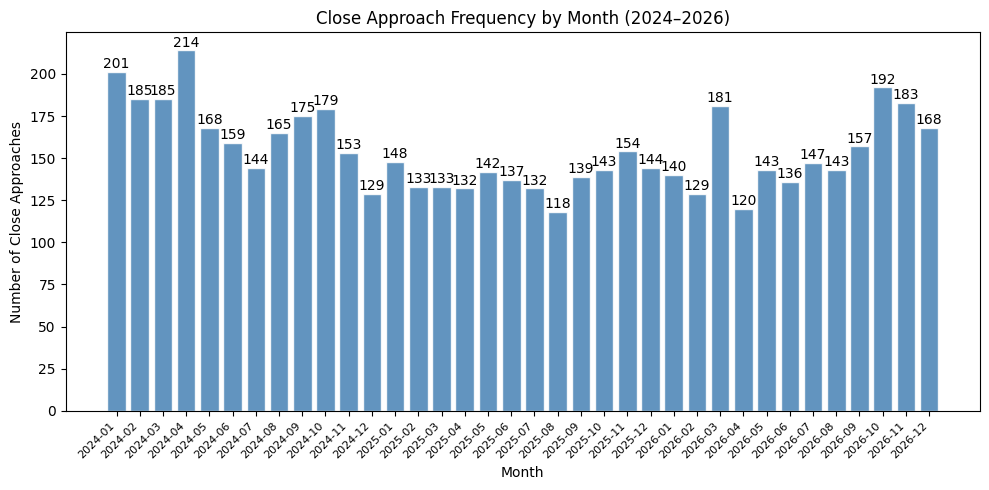

In [199]:
monthly_counts = (
    close_approaches_df["close_approach_date"]
    .dt.to_period("M")
    .value_counts()
    .sort_index()
)

counts = monthly_counts.to_numpy()

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    monthly_counts.index.astype(str),
    counts,
    color="steelblue",
    edgecolor="white",
    alpha=0.85,
)

ax.set_xlabel("Month")
ax.set_ylabel("Number of Close Approaches")
ax.set_title("Close Approach Frequency by Month (2024–2026)")

for i, v in enumerate(counts):
    ax.text(i, v + 0.5, str(v), ha="center", va="bottom", fontsize=10)

plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

#### Summary

The dataset now covers **36 months** (January 2024 – December 2026). Monthly close approach counts range from **118** (August 2025) to **214** (April 2024), a spread of 96 approaches.

| Year | Jan | Feb | Mar | Apr | May | Jun | Jul | Aug | Sep | Oct | Nov | Dec |
|---|---|---|---|---|---|---|---|---|---|---|---|---|
| 2024 | 201 | 185 | 185 | 214 | 168 | 159 | 144 | 165 | 175 | 179 | 153 | 129 |
| 2025 | 148 | 133 | 133 | 132 | 142 | 137 | 132 | 118 | 139 | 143 | 154 | 144 |
| 2026 | 140 | 129 | 181 | 120 | 143 | 136 | 143 | 147 | 157 | 192 | 183 | 168 |

**April 2024** is the busiest month (214 approaches), while **August 2025** is the quietest (118). Across all 36 months the average is approximately **154 approaches per month**. No months are incomplete — the dataset covers the full calendar period through December 31, 2026.

### 4.4.5 Interpret Findings

**Clustering**

Miss distances are not uniformly spread — they cluster heavily at larger distances (10 million km and above), as shown by the rising histogram in 4.4.2. Very close approaches (sub-lunar or within a few million km) are rare outliers. In time, **April 2024** shows the strongest clustering of encounters with 214 approaches in a single month. The closest-approach table (4.4.3) also reveals spatial clustering through catalog alias pairs: the same physical object appearing under two different IDs on the same date inflates apparent encounter counts at specific distances. One such alias pair was identified in 4.4.3 ((2026 EK1) / (2015 EX)); no duplicate pairs appeared in the velocity top-20 (4.3.3).

**Trends**

Monthly approach frequency is relatively stable across the dataset, ranging from **118** (August 2025) to **214** (April 2024), with an average of **~154 per month** over 36 months. No strong directional trend is visible across the full 2024–2026 window. March appears elevated in both 2024 (185) and 2026 (181) but not in 2025 (133), suggesting any seasonal pattern is inconsistent rather than structural. With three years of data, some year-to-year variation is visible — 2024 averaged ~171/month while 2025 averaged ~138/month and 2026 averaged ~153/month — but the sample is still too small to draw conclusions about long-term trends or confirmed seasonality.

**Limitations**

- **Date range:** The dataset covers January 2024–December 2026 (3 years). While this is substantially more data than the original 6-month snapshot, multi-decade trends and deep seasonal patterns still cannot be reliably assessed from this window.
- **Catalog aliases:** Multiple asteroid IDs mapping to the same physical object create near-duplicate rows in `close_approaches`, slightly inflating total counts and skewing ranked tables. This is an upstream data quality issue from the NASA NeoWs API.
- **Missing orbital data:** Records in `orbital_parameters.data_arc_in_days` with null values may affect any future analysis that relies on observational arc length.
- **Single orbiting body:** All approaches in the dataset are relative to Earth — no multi-body comparison is possible with the current schema.

## Hazardous Object Population Study

### 4.5.1 Segment Hazardous vs Non-Hazardous Objects

In [200]:
hazardous_df = asteroids_df[asteroids_df["is_potentially_hazardous"]].copy()
non_hazardous_df = asteroids_df[~asteroids_df["is_potentially_hazardous"]].copy()

total = len(asteroids_df)
summary = pd.DataFrame({
    "count": [len(hazardous_df), len(non_hazardous_df), total],
    "percentage": [
        len(hazardous_df) / total * 100,
        len(non_hazardous_df) / total * 100,
        100.0,
    ],
}, index=["Potentially Hazardous", "Non-Hazardous", "Total"])
summary["percentage"] = summary["percentage"].map("{:.2f}%".format)

display(summary)

,count,percentage
Potentially Hazardous,527,12.90%
Non-Hazardous,3557,87.10%
Total,4084,100.00%


### 4.5.2 Compare Diameter Characteristics

,Hazardous (n=90),Non-Hazardous (n=738)
mean,0.574105,0.256011
median,0.428588,0.103762
std,0.456542,0.939147
min,0.188817,0.002061
max,5.248558,49.435619


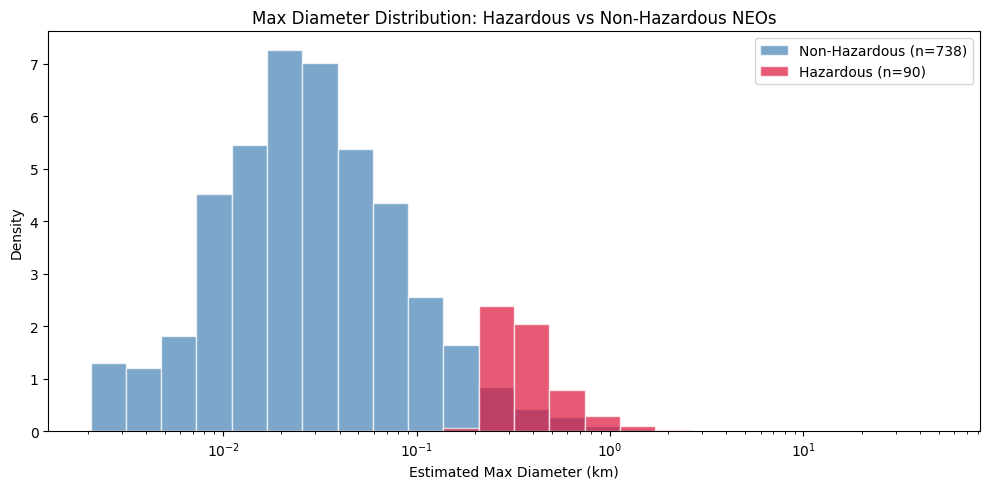

In [201]:
diameter_col = "estimated_diameter_max_km"

diameter_comparison = pd.DataFrame({
    "Hazardous (n=90)": hazardous_df[diameter_col].agg(["mean", "median", "std", "min", "max"]),
    "Non-Hazardous (n=738)": non_hazardous_df[diameter_col].agg(["mean", "median", "std", "min", "max"]),
}).round(6)

display(diameter_comparison)

bins = np.logspace(
    np.log10(asteroids_df[diameter_col].min()),
    np.log10(asteroids_df[diameter_col].max()),
    25,
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(non_hazardous_df[diameter_col], bins=bins, density=True,
        color="steelblue", edgecolor="white", alpha=0.7, label="Non-Hazardous (n=738)")
ax.hist(hazardous_df[diameter_col], bins=bins, density=True,
        color="crimson", edgecolor="white", alpha=0.7, label="Hazardous (n=90)")

ax.set_xscale("log")
ax.set_xlabel("Estimated Max Diameter (km)")
ax.set_ylabel("Density")
ax.set_title("Max Diameter Distribution: Hazardous vs Non-Hazardous NEOs")
ax.legend()

plt.tight_layout()
plt.show()

#### Summary

| Statistic | Hazardous (n=90) | Non-Hazardous (n=738) |
|---|---|---|
| mean | 0.574105 km | 0.256011 km |
| median | 0.428588 km | 0.103762 km |
| std | 0.456542 km | 0.939147 km |
| min | 0.188817 km | 0.002061 km |
| max | 5.248558 km | 49.435619 km |

Hazardous asteroids are **substantially larger** on every central measure. The median PHO (~429 m) is roughly **~4.1× larger** than the median non-hazardous asteroid (~104 m). The mean gap is also notable (~2.2×). This is expected: NASA's PHO definition requires an absolute magnitude H ≤ 22, which corresponds to a minimum diameter of roughly 140 m — so small objects cannot be classified as hazardous regardless of their orbit.

The non-hazardous group has a much higher maximum (49.44 km vs 5.25 km) because large asteroids — including 433 Eros, the largest object in the dataset — have favorable orbits that do not bring them close enough to Earth to qualify as PHOs. The density-normalized histogram makes the size separation visually clear: the hazardous distribution (crimson) is shifted distinctly to the right of the non-hazardous distribution (blue).

### 4.5.3 Compare Velocity Characteristics

,Hazardous (n=616),Non-Hazardous (n=4935)
mean,17.114444,13.459197
median,16.468085,12.611136
std,7.167023,6.888378
min,3.784329,0.256356
max,40.420044,51.704413


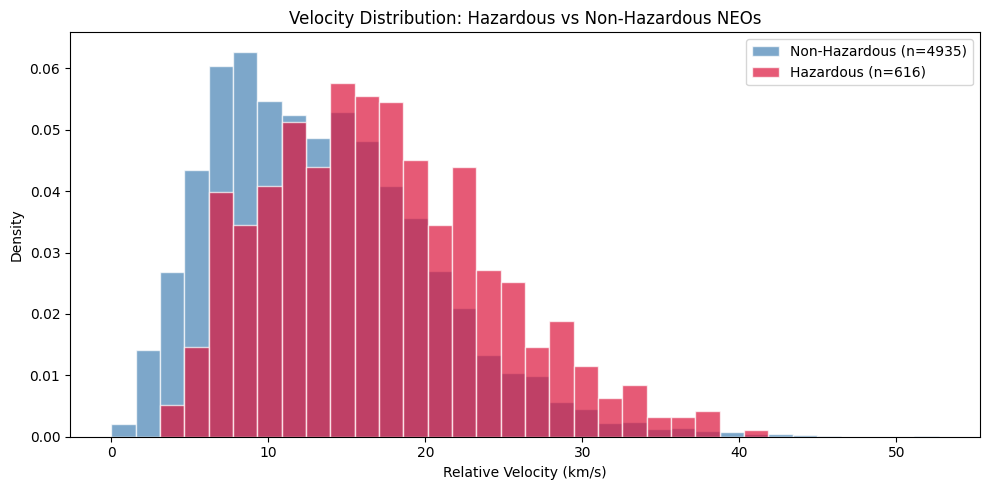

In [202]:
hazardous_ca = close_approaches_df[close_approaches_df["asteroid_id"].isin(hazardous_df["asteroid_id"])]
non_hazardous_ca = close_approaches_df[close_approaches_df["asteroid_id"].isin(non_hazardous_df["asteroid_id"])]

agg_stats = ["mean", "median", "std", "min", "max"]
velocity_comparison = pd.DataFrame({
    f"Hazardous (n={len(hazardous_ca)})": hazardous_ca["relative_velocity_kps"].agg(agg_stats),
    f"Non-Hazardous (n={len(non_hazardous_ca)})": non_hazardous_ca["relative_velocity_kps"].agg(agg_stats),
}).round(6)

display(velocity_comparison)

bins = np.linspace(0, close_approaches_df["relative_velocity_kps"].max() + 1, 35)

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(non_hazardous_ca["relative_velocity_kps"], bins=bins, density=True,
        color="steelblue", edgecolor="white", alpha=0.7, label=f"Non-Hazardous (n={len(non_hazardous_ca)})")
ax.hist(hazardous_ca["relative_velocity_kps"], bins=bins, density=True,
        color="crimson", edgecolor="white", alpha=0.7, label=f"Hazardous (n={len(hazardous_ca)})")

ax.set_xlabel("Relative Velocity (km/s)")
ax.set_ylabel("Density")
ax.set_title("Velocity Distribution: Hazardous vs Non-Hazardous NEOs")
ax.legend()

plt.tight_layout()
plt.show()

#### Summary

| Statistic | Hazardous (n=616) | Non-Hazardous (n=4935) |
|---|---|---|
| mean | 17.114444 km/s | 13.459197 km/s |
| median | 16.468085 km/s | 12.611136 km/s |
| std | 7.167023 km/s | 6.888378 km/s |
| min | 3.784329 km/s | 0.256356 km/s |
| max | 40.420044 km/s | 51.704413 km/s |

Hazardous asteroids approach at **higher velocities on average** — a median of ~16.5 km/s vs ~12.6 km/s for non-hazardous objects (~31% faster). This is consistent with the orbital dynamics underlying PHO classification: hazardous asteroids tend to have higher eccentricities and inclinations, which produce more energetic Earth-crossing geometries.

Unlike the diameter comparison, the velocity distributions **do overlap substantially** — both groups span a similar range and have comparable standard deviations (~7 km/s). Velocity alone is therefore a weak discriminator between the two groups; the offset in the mean is real but the spread is large. The fastest approach in the dataset (51.70 km/s) belongs to a non-hazardous asteroid, confirming that extreme velocities are not exclusive to PHOs.

### 4.5.4 Compare Miss Distance Characteristics

,Hazardous (n=616),Non-Hazardous (n=4935)
mean,31659471.73,40840718.14
median,25170524.18,41290990.01
std,21753030.76,20402253.59
min,2209273.54,136610.52
max,74646708.08,74791690.68


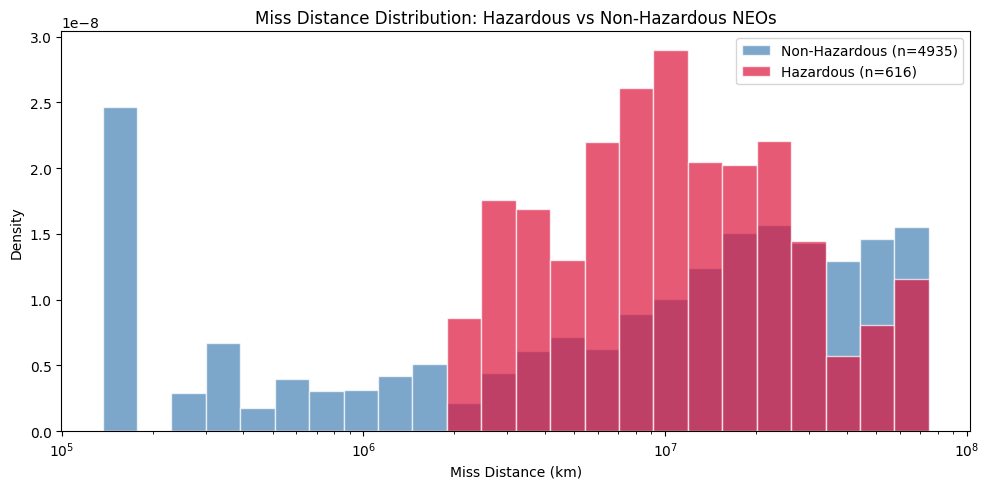

In [203]:
miss_col = "miss_distance_km"

miss_comparison = pd.DataFrame({
    f"Hazardous (n={len(hazardous_ca)})": hazardous_ca[miss_col].agg(agg_stats),
    f"Non-Hazardous (n={len(non_hazardous_ca)})": non_hazardous_ca[miss_col].agg(agg_stats),
}).round(2)

display(miss_comparison)

bins = np.logspace(
    np.log10(close_approaches_df[miss_col].min()),
    np.log10(close_approaches_df[miss_col].max()),
    25,
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(non_hazardous_ca[miss_col], bins=bins, density=True,
        color="steelblue", edgecolor="white", alpha=0.7, label=f"Non-Hazardous (n={len(non_hazardous_ca)})")
ax.hist(hazardous_ca[miss_col], bins=bins, density=True,
        color="crimson", edgecolor="white", alpha=0.7, label=f"Hazardous (n={len(hazardous_ca)})")

ax.set_xscale("log")
ax.set_xlabel("Miss Distance (km)")
ax.set_ylabel("Density")
ax.set_title("Miss Distance Distribution: Hazardous vs Non-Hazardous NEOs")
ax.legend()

plt.tight_layout()
plt.show()

#### Summary

| Statistic | Hazardous (n=616) | Non-Hazardous (n=4935) |
|---|---|---|
| mean | 31,659,472 km | 40,840,718 km |
| median | 25,170,524 km | 41,290,990 km |
| std | 21,753,031 km | 20,402,254 km |
| min | 2,209,274 km | 136,611 km |
| max | 74,646,708 km | 74,791,691 km |

Hazardous asteroids pass closer to Earth on average — median ~25.2M km vs ~41.3M km for non-hazardous, roughly **1.6× closer**. This follows directly from the PHO classification criteria: NASA's definition requires a Minimum Orbit Intersection Distance (MOID) ≤ 0.05 AU (~7.48M km), meaning PHOs are specifically the asteroids whose orbital paths come within that threshold of Earth's orbit. The classification selects for proximity by design, so smaller miss distances in this group are expected.

The histogram reflects this clearly — hazardous approaches (crimson) are concentrated in the 5–50M km band, while non-hazardous approaches (blue) spread more broadly, with a notable high-density spike below 1M km driven by the repeated close passes of (2025 US6), and elevated density again at large distances.

Notably, the closest absolute approach in the dataset (~136.6K km, sub-lunar) belongs to a **non-hazardous** asteroid, (2025 US6), which made multiple passes well inside the Moon's distance during 2025. The closest hazardous approach is ~2.21M km. Both groups share a similar upper bound (~74.6–74.8M km), reflecting the outer edge of NASA's close-approach tracking window rather than a physical difference. The standard deviations (~20–22M km each) confirm the spread is comparable between groups — the separation is in the center, not the tails.

### 4.5.5 Identify Potential Predictive Features

,feature,correlation
rank,,
1,absolute_magnitude_h,-0.3838
2,eccentricity,0.2355
3,minimum_orbit_intersection,-0.2069
4,perihelion_distance,-0.1543
5,aphelion_distance,0.1541
6,min_miss_distance_km,-0.1433
7,max_relative_velocity_kps,0.1331
8,estimated_diameter_max_km,0.1188
9,jupiter_tisserand_invariant,-0.1070


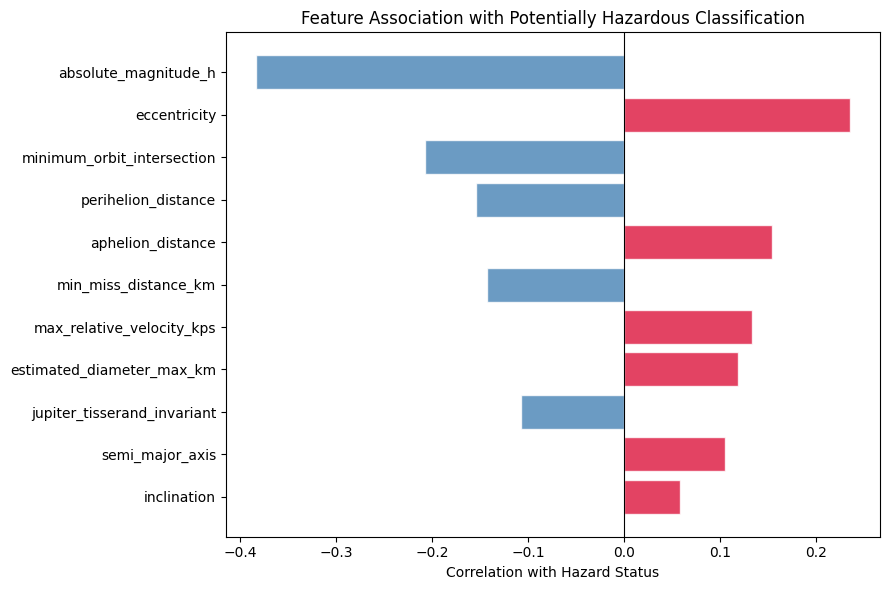

In [204]:

# Per-asteroid close approach aggregates
ca_agg = (
    close_approaches_df
    .groupby("asteroid_id")
    .agg(
        min_miss_distance_km=("miss_distance_km", "min"),
        max_relative_velocity_kps=("relative_velocity_kps", "max"),
    )
    .reset_index()
)

# Build asteroid-level feature matrix
orbital_cols = [
    "asteroid_id", "minimum_orbit_intersection", "eccentricity",
    "inclination", "semi_major_axis", "perihelion_distance",
    "aphelion_distance", "jupiter_tisserand_invariant",
]

features_df = (
    asteroids_df[["asteroid_id", "absolute_magnitude_h",
                  "estimated_diameter_max_km", "is_potentially_hazardous"]]
    .merge(orbital_parameters_df[orbital_cols], on="asteroid_id", how="left")
    .merge(ca_agg, on="asteroid_id", how="left")
)

# Point-biserial correlation (equivalent to Pearson for binary target)
feature_cols = [
    c for c in features_df.columns
    if c not in ("asteroid_id", "is_potentially_hazardous")
]
target = features_df["is_potentially_hazardous"].astype(int)

corr_df = (
    features_df[feature_cols]
    .corrwith(target)
    .rename("correlation")
    .to_frame()
    .assign(abs_corr=lambda df: df["correlation"].abs())
    .sort_values("abs_corr", ascending=False)
    .drop(columns="abs_corr")
    .round(4)
)
corr_df.index.name = "feature"
corr_df = corr_df.reset_index()
corr_df.index += 1
corr_df.index.name = "rank"

display(corr_df)

# Horizontal bar chart
fig, ax = plt.subplots(figsize=(9, 6))

features_rev = corr_df["feature"][::-1].tolist()
corrs_rev = corr_df["correlation"][::-1].tolist()
bar_colors = ["crimson" if r >= 0 else "steelblue" for r in corrs_rev]

ax.barh(features_rev, corrs_rev, color=bar_colors, edgecolor="white", alpha=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Correlation with Hazard Status")
ax.set_title("Feature Association with Potentially Hazardous Classification")

plt.tight_layout()
plt.show()


#### Summary

Correlations are computed as point-biserial (equivalent to Pearson for a binary target), ranked by absolute value across 11 candidate features.

| Rank | Feature | Correlation | Interpretation |
|---|---|---|---|
| 1 | `absolute_magnitude_h` | −0.3838 | Smaller H (brighter/larger) → more likely hazardous |
| 2 | `eccentricity` | +0.2355 | More elongated orbit → more likely hazardous |
| 3 | `minimum_orbit_intersection` | −0.2069 | Smaller MOID → more likely hazardous |
| 4 | `perihelion_distance` | −0.1543 | Orbit dips closer to the Sun → more likely hazardous |
| 5 | `aphelion_distance` | +0.1541 | Orbit extends further out → more likely hazardous |
| 6 | `min_miss_distance_km` | −0.1433 | Closer minimum pass → more likely hazardous |
| 7 | `max_relative_velocity_kps` | +0.1331 | Faster approach speed → more likely hazardous |
| 8 | `estimated_diameter_max_km` | +0.1188 | Larger diameter → more likely hazardous |
| 9 | `jupiter_tisserand_invariant` | −0.1070 | Lower TJ → more likely hazardous |
| 10 | `semi_major_axis` | +0.1052 | Larger orbit → more likely hazardous |
| 11 | `inclination` | +0.0587 | Weakest individual signal |

**Absolute magnitude is the strongest single predictor.** `absolute_magnitude_h` (|r| = 0.38) leads the ranking, reflecting NASA's H ≤ 22 size requirement built into the PHO definition. Because small asteroids (H > 22) vastly outnumber large ones, the size criterion alone cleaves the hazardous from non-hazardous population more than any orbital feature.

**`estimated_diameter_max_km` ranks lower than expected at rank 8** (|r| = 0.12). Diameter and H are highly correlated (both measure size), but diameter is a derived estimate computed from H via an assumed albedo. The direct magnitude measure (H) captures more of the size-hazard signal, making the diameter redundant in this ranking.

**Eccentricity (rank 2) and MOID (rank 3) are the strongest orbital features.** At |r| = 0.24 and 0.21 respectively, both sit close behind absolute magnitude. MOID at rank 3 makes strong physical sense — it is one of the two defining PHO criteria (MOID ≤ 0.05 AU) — while eccentricity independently captures the orbital geometry that produces Earth-crossing trajectories.

**No single feature is sufficient.** All correlations are below |r| = 0.39, meaning none of the individual features cleanly separates the two groups on its own. A reliable hazard classifier would need to combine multiple features — particularly size (H), eccentricity, and MOID — rather than rely on any one signal alone.

## Correlation & Relationship Analysis

### 4.6.1 Create Correlation Matrix

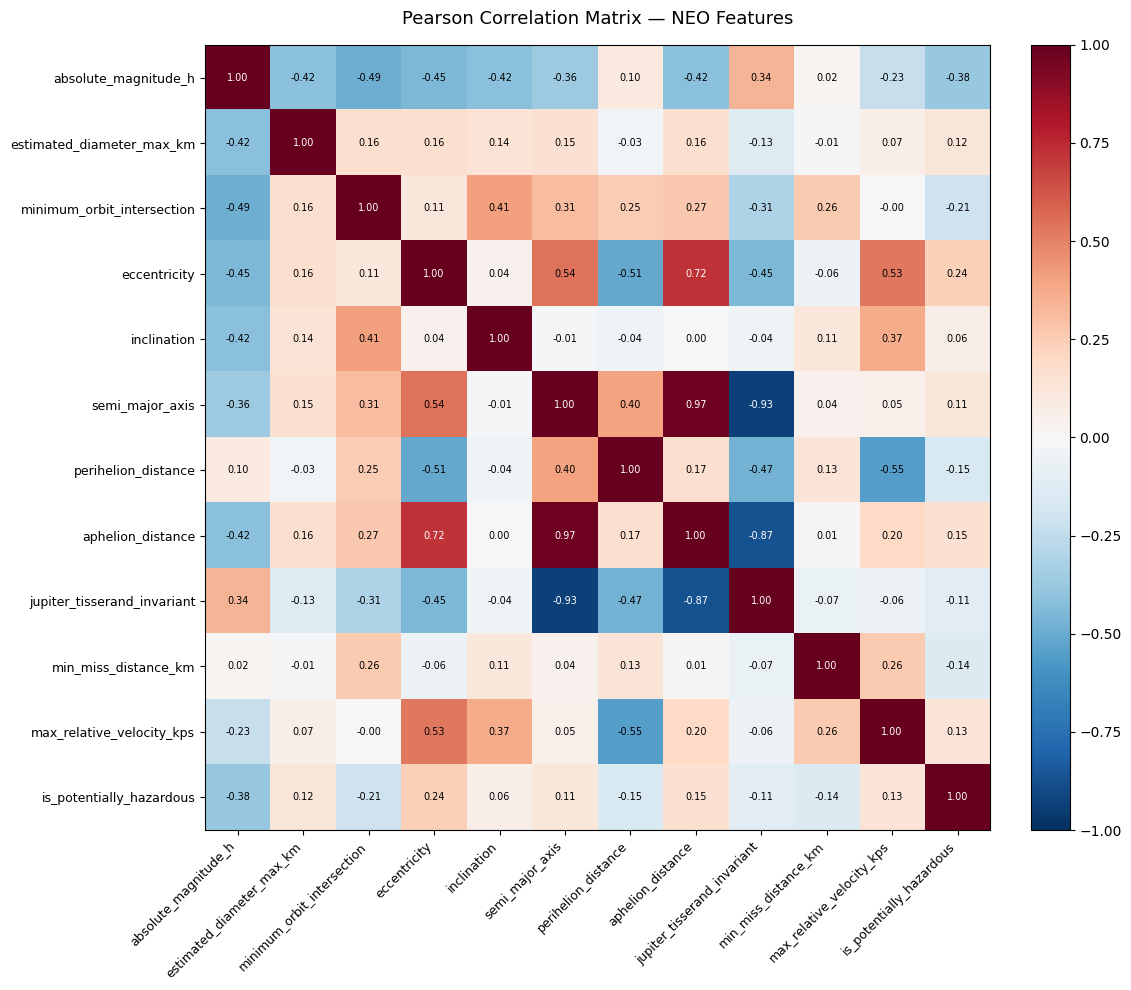

In [205]:
corr_matrix = (
    features_df[feature_cols]
    .assign(is_potentially_hazardous=features_df["is_potentially_hazardous"].astype(int))
    .corr()
    .round(2)
)

fig, ax = plt.subplots(figsize=(12, 10))

im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

labels = corr_matrix.columns.tolist()
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(labels, fontsize=9)

for i in range(len(labels)):
    for j in range(len(labels)):
        val = corr_matrix.iloc[i, j]
        text_color = "white" if abs(val) > 0.6 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=7, color=text_color)

ax.set_title("Pearson Correlation Matrix — NEO Features", fontsize=13, pad=15)
plt.tight_layout()
plt.show()


### 4.6.2 Analyze Size vs Velocity

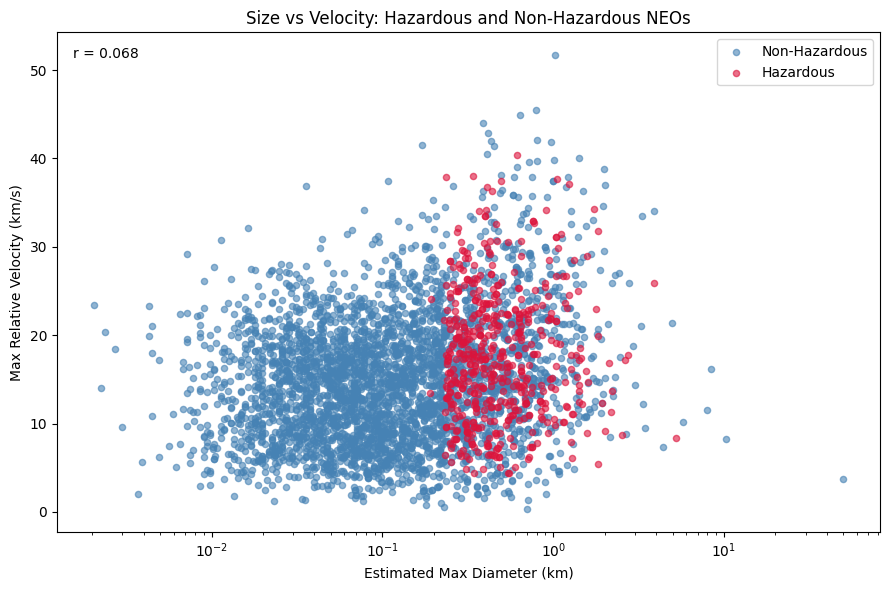

In [206]:
scatter_df = features_df[
    ["estimated_diameter_max_km", "max_relative_velocity_kps", "is_potentially_hazardous"]
].dropna()

r = scatter_df["estimated_diameter_max_km"].corr(scatter_df["max_relative_velocity_kps"])

fig, ax = plt.subplots(figsize=(9, 6))

for label, group_bool, color in [
    ("Non-Hazardous", False, "steelblue"),
    ("Hazardous", True, "crimson"),
]:
    mask = scatter_df["is_potentially_hazardous"] == group_bool
    ax.scatter(
        scatter_df.loc[mask, "estimated_diameter_max_km"],
        scatter_df.loc[mask, "max_relative_velocity_kps"],
        c=color, alpha=0.6, s=20, label=label,
    )

ax.set_xscale("log")
ax.set_xlabel("Estimated Max Diameter (km)")
ax.set_ylabel("Max Relative Velocity (km/s)")
ax.set_title("Size vs Velocity: Hazardous and Non-Hazardous NEOs")
ax.legend()
ax.text(0.02, 0.97, f"r = {r:.3f}", transform=ax.transAxes, va="top", fontsize=10)

plt.tight_layout()
plt.show()


### 4.6.3 Analyze Size vs Miss Distance

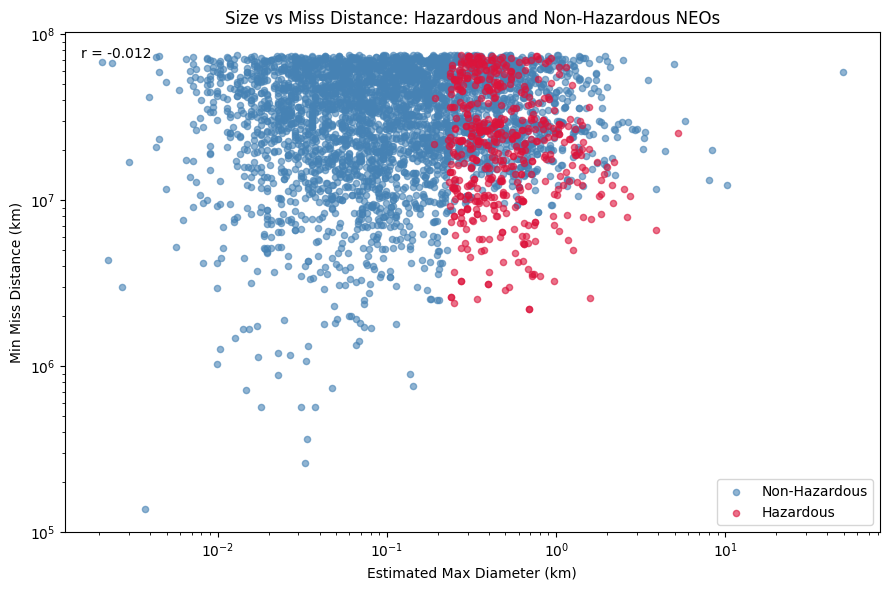

In [207]:
scatter_df2 = features_df[
    ["estimated_diameter_max_km", "min_miss_distance_km", "is_potentially_hazardous"]
].dropna()

r2 = scatter_df2["estimated_diameter_max_km"].corr(scatter_df2["min_miss_distance_km"])

fig, ax = plt.subplots(figsize=(9, 6))

for label, group_bool, color in [
    ("Non-Hazardous", False, "steelblue"),
    ("Hazardous", True, "crimson"),
]:
    mask = scatter_df2["is_potentially_hazardous"] == group_bool
    ax.scatter(
        scatter_df2.loc[mask, "estimated_diameter_max_km"],
        scatter_df2.loc[mask, "min_miss_distance_km"],
        c=color, alpha=0.6, s=20, label=label,
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Estimated Max Diameter (km)")
ax.set_ylabel("Min Miss Distance (km)")
ax.set_title("Size vs Miss Distance: Hazardous and Non-Hazardous NEOs")
ax.legend()
ax.text(0.02, 0.97, f"r = {r2:.3f}", transform=ax.transAxes, va="top", fontsize=10)

plt.tight_layout()
plt.show()


### 4.6.4 Interpret Correlation Findings

#### Meaningful Relationships

**Orbital geometry clusters (r ≥ 0.87)**

The three strongest correlations in the matrix are between orbital parameters that are mathematically linked by Keplerian mechanics:

- `semi_major_axis` ↔ `aphelion_distance`: r = **0.97** — aphelion = a(1 + e), so for similar eccentricities, aphelion scales almost perfectly with semi-major axis. The near-perfect r reflects that variation in semi-major axis dominates over variation in eccentricity across this dataset.
- `semi_major_axis` ↔ `jupiter_tisserand_invariant`: r = **−0.93** — the Tisserand parameter TJ increases as an asteroid's orbit shrinks (smaller semi-major axis → higher TJ), producing the strong negative trend.
- `aphelion_distance` ↔ `jupiter_tisserand_invariant`: r = **−0.87** — a downstream consequence of the two above.

These three values are structural: they reflect the mathematics of orbital mechanics rather than independent physical properties. They are not useful as independent inputs to a risk model since they encode the same underlying orbital shape.

**Eccentricity as a velocity driver (r = 0.53)**

`eccentricity` ↔ `max_relative_velocity_kps`: r = **0.53** — more elongated orbits cross Earth's path at higher relative speeds. This is the strongest physically meaningful relationship between an orbital property and an observable approach characteristic. It is reinforced by `perihelion_distance` ↔ `max_relative_velocity_kps` (r = −0.55): orbits that dip closer to the Sun at perihelion produce faster encounters at Earth distance.

**Size ↔ magnitude (r = −0.42)**

`absolute_magnitude_h` ↔ `estimated_diameter_max_km`: r = **−0.42** — the expected inverse: smaller H means a brighter, larger object. These two columns measure the same physical property through different proxies (photometric vs. modeled diameter). The moderate correlation — rather than a near-perfect one — reflects the uncertainty introduced by the assumed albedo when converting H to diameter. Despite the moderate r, both features should not be fed into a model as independent inputs; they are redundant measures of the same underlying property.

---

#### Weak Relationships

**Size vs velocity (r = 0.068)**

The scatter plot (4.6.2) shows substantial spread with essentially no trend — the r = 0.068 is negligible. Larger asteroids are not meaningfully faster on average, and the velocity range is nearly identical for hazardous (crimson) and non-hazardous (blue) objects at any given size. Size and velocity are effectively independent properties of an asteroid in this dataset.

**Size vs miss distance (r = −0.012)**

The log-log scatter (4.6.3) shows no meaningful correlation. Miss distance and diameter are essentially independent — the near-zero r confirms there is no detectable linear relationship between an asteroid's size and how close it passes to Earth.

**MOID as a predictor (r = −0.21 with hazard status)**

`minimum_orbit_intersection` correlates more strongly with `absolute_magnitude_h` (r = −0.49) than with `is_potentially_hazardous` (r = −0.21), despite MOID being one of the two defining PHO criteria. The reason: many non-hazardous asteroids have low MOIDs but are too small (H > 22) to qualify as PHOs. In this sample the size criterion eliminates far more candidates than the MOID threshold, so the MOID signal is diluted — though at |r| = 0.21, it is still the third-strongest predictor of hazard status after absolute magnitude and eccentricity.

---

#### Surprises

**The closest approaches belong to non-hazardous asteroids.**

In the size vs miss distance plot (4.6.3), the bottom of the chart — the very closest observed passes — is populated entirely by non-hazardous asteroids (blue). The closest hazardous approach in the dataset is ~2.21M km. The overall closest approach belongs to a non-hazardous asteroid, (2025 US6), at ~136.6K km — well inside the Moon's distance. This seems to contradict the PHO classification, but reflects the difference between an orbit's MOID (minimum possible approach distance, used to classify PHOs) and the closest actual approach that occurred within the dataset window. A PHO's MOID may be ≤ 0.05 AU, but its observed passes need not be anywhere near that minimum during any given period.

**Velocity increases with inclination (r = 0.37).**

`inclination` ↔ `max_relative_velocity_kps`: r = **0.37** is a moderately meaningful relationship: high-inclination orbits cross Earth's orbital plane at a steeper angle, adding a vertical velocity component that raises the total relative speed at closest approach. This is independent of eccentricity and represents a separate velocity pathway worth considering in a risk model.

## Outlier Investigation

### 4.7.1 Identify Largest Outliers

3× IQR upper fence: 1.2511 km
Outliers identified: 128


,asteroid_id,name,estimated_diameter_max_km,absolute_magnitude_h,is_potentially_hazardous
rank,,,,,
1,2000433,433 Eros (A898 PA),49.435619,10.40,False
2,2000887,887 Alinda (A918 AA),10.233872,13.82,False
3,2001685,1685 Toro (1948 OA),8.356799,14.26,False
4,2066146,66146 (1998 TU3),7.980681,14.36,False
5,2138205,138205 (2000 EZ148),5.728488,15.08,False
...,...,...,...,...,...
124,2173561,173561 (2000 YV137),1.264853,18.36,True
125,2190788,190788 (2001 RT17),1.264853,18.36,False
126,2065733,65733 (1993 PC),1.259041,18.37,False


is_potentially_hazardous
False    92
True     36
Name: count, dtype: int64


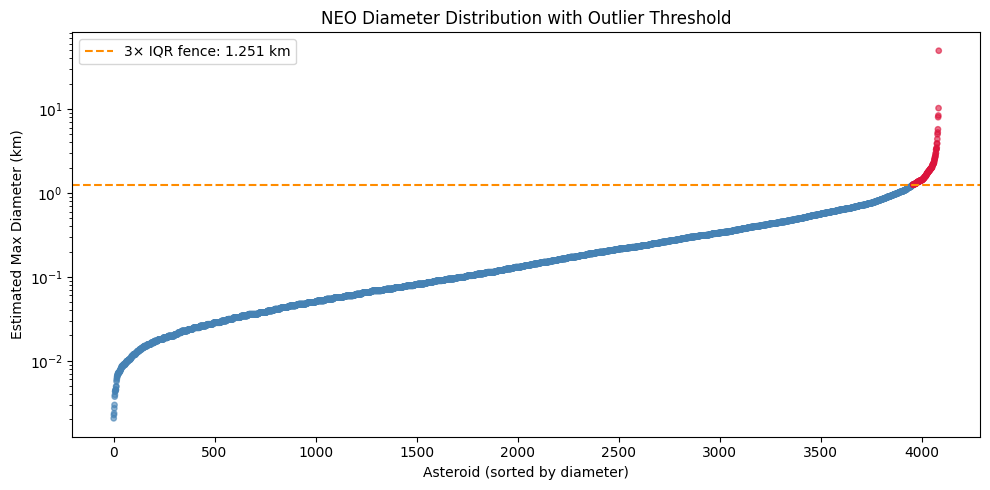

In [208]:
Q1 = asteroids_df["estimated_diameter_max_km"].quantile(0.25)
Q3 = asteroids_df["estimated_diameter_max_km"].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 3 * IQR

size_outliers = (
    asteroids_df[asteroids_df["estimated_diameter_max_km"] > upper_fence]
    [["asteroid_id", "name", "estimated_diameter_max_km",
      "absolute_magnitude_h", "is_potentially_hazardous"]]
    .sort_values("estimated_diameter_max_km", ascending=False)
    .reset_index(drop=True)
)
size_outliers.index += 1
size_outliers.index.name = "rank"

print(f"3× IQR upper fence: {upper_fence:.4f} km")
print(f"Outliers identified: {len(size_outliers)}")
display(size_outliers)
print(size_outliers['is_potentially_hazardous'].value_counts())


fig, ax = plt.subplots(figsize=(10, 5))

sorted_diameters = asteroids_df["estimated_diameter_max_km"].sort_values().to_numpy(dtype=float)
point_colors = ["crimson" if v > upper_fence else "steelblue" for v in sorted_diameters]

ax.scatter(range(1, len(asteroids_df) + 1), sorted_diameters,
           c=point_colors, alpha=0.6, s=15)
ax.axhline(upper_fence, color="darkorange", linestyle="--", linewidth=1.5,
           label=f"3× IQR fence: {upper_fence:.3f} km")
ax.set_yscale("log")
ax.set_xlabel("Asteroid (sorted by diameter)")
ax.set_ylabel("Estimated Max Diameter (km)")
ax.set_title("NEO Diameter Distribution with Outlier Threshold")
ax.legend()

plt.tight_layout()
plt.show()

#### Summary

Using the 3× IQR method (consistent with the flagging in 4.1.4), the upper fence falls at **1.251 km**. **128 asteroids** exceed this threshold and are classified as size outliers — representing the top ~3.1% of the 4,084-asteroid dataset.

The scatter plot makes the outlier structure visually clear. The bulk of the dataset traces a smooth, continuous curve on a log scale — a log-normal distribution rising from ~0.003 km to just below the fence. Above 1.251 km, the 128 crimson points form a distinct cluster that breaks sharply upward, with the top few objects (including 433 Eros at ~49.4 km) separated noticeably from the rest of the outlier group.

**These outliers are physically real, not data errors.** All 128 are named or catalogued asteroids with valid diameter estimates derived from NASA's size estimation model. Their large diameters are consistent with their bright absolute magnitudes (H values ranging from ~10 to ~18, well below the H ≤ 22 PHO size threshold). No impossible values were flagged for any of these objects in 4.1.3.

**Hazard context:** Of the 128 outliers, 36 (28%) are potentially hazardous and 92 (72%) are non-hazardous — consistent with the 4.5.2 finding that PHOs are substantially larger than non-hazardous asteroids (PHO median ~429 m vs. non-hazardous median ~104 m). Their scale also means any close approach carries disproportionately higher impact energy, making them the highest-priority objects for continued monitoring regardless of current miss distance.

### 4.7.2 Identify Velocity Outliers

Q1: 8.459 km/s  |  Q3: 18.148 km/s  |  IQR: 9.689 km/s
1.5× IQR upper fence: 32.681 km/s
Outliers identified: 79


,name,asteroid_id,close_approach_date,relative_velocity_kps,miss_distance_km,is_potentially_hazardous
rank,,,,,,
1,504181 (2006 TC),2504181,2025-10-12,51.704413,7.471847e+07,False
2,(2013 LC7),3639550,2026-05-31,45.517616,6.704966e+07,False
3,(2018 GG5),3803884,2024-02-18,44.866916,4.569786e+07,False
4,(2017 WP28),3790060,2024-01-13,43.966629,7.405282e+07,False
5,(2008 QB),3425295,2024-08-02,42.871224,7.438070e+07,False
...,...,...,...,...,...,...
75,612012 (1983 LC),2612012,2025-12-10,32.956221,7.395417e+07,True
76,(2015 HQ10),3717050,2026-04-25,32.923722,3.755234e+07,False
77,(2006 UB64),3353630,2025-05-18,32.820032,7.048161e+07,False


is_potentially_hazardous
False    61
True     18
Name: count, dtype: int64


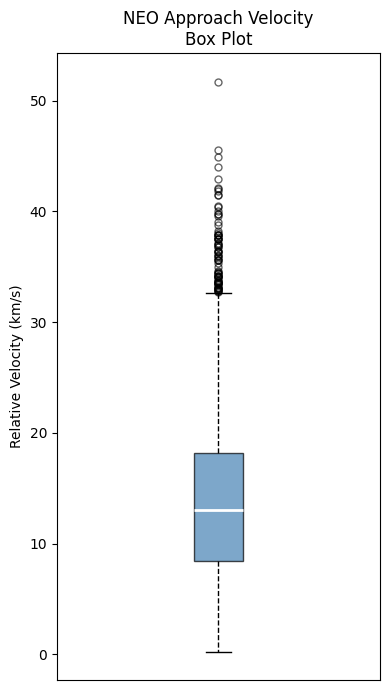

In [209]:
vel = close_approaches_df["relative_velocity_kps"]
Q1_v = vel.quantile(0.25)
Q3_v = vel.quantile(0.75)
IQR_v = Q3_v - Q1_v
upper_fence_v = Q3_v + 1.5 * IQR_v

vel_outliers = (
    close_approaches_df[vel > upper_fence_v]
    .merge(asteroids_df[["asteroid_id", "name", "is_potentially_hazardous"]],
           on="asteroid_id", how="left")
    [["name", "asteroid_id", "close_approach_date",
      "relative_velocity_kps", "miss_distance_km", "is_potentially_hazardous"]]
    .sort_values("relative_velocity_kps", ascending=False)
    .reset_index(drop=True)
)
vel_outliers.index += 1
vel_outliers.index.name = "rank"

print(f"Q1: {Q1_v:.3f} km/s  |  Q3: {Q3_v:.3f} km/s  |  IQR: {IQR_v:.3f} km/s")
print(f"1.5× IQR upper fence: {upper_fence_v:.3f} km/s")
print(f"Outliers identified: {len(vel_outliers)}")
display(vel_outliers)
print(vel_outliers['is_potentially_hazardous'].value_counts())


fig, ax = plt.subplots(figsize=(4, 7))
ax.boxplot(
    vel.to_numpy(dtype=float),
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.7),
    medianprops=dict(color="white", linewidth=2),
    flierprops=dict(marker="o", color="crimson", alpha=0.6, markersize=5),
    whiskerprops=dict(linestyle="--"),
)
ax.set_ylabel("Relative Velocity (km/s)")
ax.set_title("NEO Approach Velocity\nBox Plot")
ax.set_xticks([])
plt.tight_layout()
plt.show()

#### Summary

The standard 1.5× IQR fence is used here because the stricter 3× IQR check in 4.1.4 returned zero velocity outliers — meaning the upper tail is unusual by the common box-plot definition but not extreme enough to be considered anomalous data. The fence falls at **32.681 km/s**, yielding **79 flagged approach records**.

The outlier range spans roughly **32.7–51.7 km/s** — all in the upper ~1.4% of the 5,551-record approach dataset. Key observations from the table:

- **Fastest outlier: 504181 (2006 TC)** at **51.70 km/s** on 2025-10-12 — nearly 4× the dataset median of ~13.1 km/s and the same record already identified as the fastest approach in 4.3.3.
- **18 PHOs** appear in the outlier list — consistent with the 4.5.3 finding that hazardous asteroids have a higher average approach speed (~16.5 km/s median vs ~12.6 km/s for non-hazardous). The remaining 61 outliers are non-hazardous.
- **The (2006 UB64) alias pair** appears at ranks 77 & 78 — the same physical object under two catalog IDs, with identical velocity (32.82 km/s), date (2025-05-18), and miss distance. This inflates the flagged count by one.
- **All outlier records have large miss distances** (tens of millions of km), reinforcing the 4.6 finding that velocity and proximity are effectively independent.

The box plot confirms the structure: the IQR box occupies roughly 8.5–18.1 km/s, the upper whisker extends to the largest non-outlier value (~32.7 km/s), and the 79 outlier records appear as scattered dots above it. The distribution is right-skewed but not abnormally so — these velocities are consistent with high-eccentricity or high-inclination orbits (eccentricity–velocity r = 0.53, inclination–velocity r = 0.37 from 4.6.4) and represent genuine orbital diversity rather than data errors.

### 4.7.3 Investigate Closest Approaches

Q1: 21,930,813 km  |  Q3: 58,277,967 km  |  IQR: 36,347,154 km
1.5× IQR lower fence: -32,589,919 km
IQR outliers (below fence): 0

5th-percentile threshold: 7,682,343 km

Records at or below 5th percentile: 278


,name,asteroid_id,close_approach_date,miss_distance_km,relative_velocity_kps,is_potentially_hazardous
rank,,,,,,
1,(2025 US6),54554706,2025-11-13,1.366105e+05,2.077811,False
2,(2025 US6),54554706,2025-09-10,1.508417e+05,1.943865,False
3,(2025 US6),54554706,2025-10-28,1.510885e+05,1.950538,False
4,(2025 US6),54554706,2025-10-12,1.544241e+05,1.922091,False
5,(2025 US6),54554706,2025-12-02,1.594955e+05,1.892867,False
...,...,...,...,...,...,...
274,(2016 VS),3763271,2026-06-12,7.645401e+06,11.079159,False
275,(2019 SF6),3869336,2025-09-28,7.655216e+06,8.444019,False
276,(2016 VZ1),3763339,2026-11-05,7.657095e+06,13.482405,False


is_potentially_hazardous
False    216
True      62
Name: count, dtype: int64


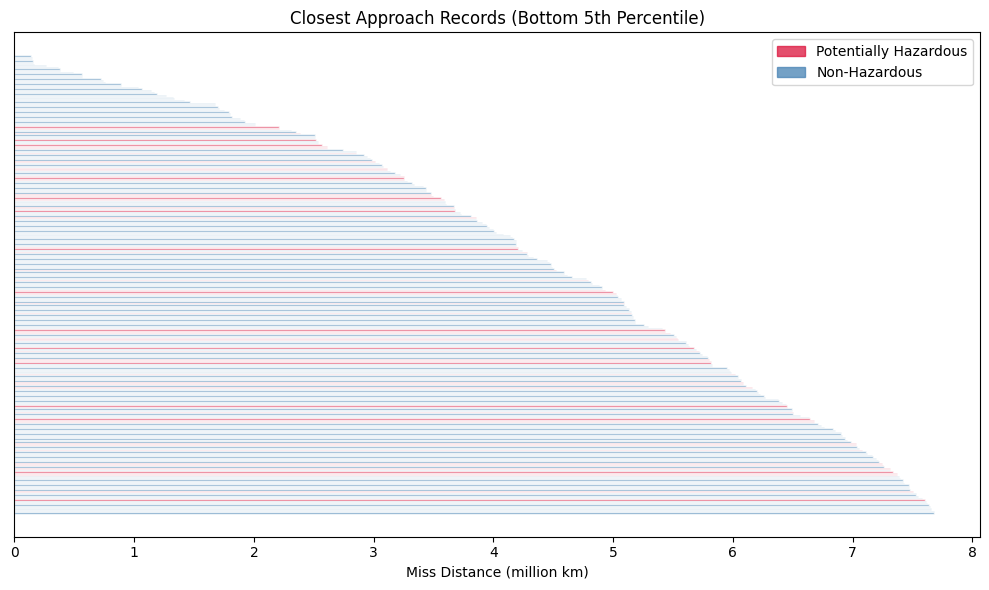

In [210]:
dist = close_approaches_df["miss_distance_km"]
Q1_d = dist.quantile(0.25)
Q3_d = dist.quantile(0.75)
IQR_d = Q3_d - Q1_d
lower_fence = Q1_d - 1.5 * IQR_d
p5_threshold = dist.quantile(0.05)

print(f"Q1: {Q1_d:,.0f} km  |  Q3: {Q3_d:,.0f} km  |  IQR: {IQR_d:,.0f} km")
print(f"1.5× IQR lower fence: {lower_fence:,.0f} km")
print(f"IQR outliers (below fence): {(dist < lower_fence).sum()}")
print(f"\n5th-percentile threshold: {p5_threshold:,.0f} km")

close_outliers = (
    close_approaches_df[dist <= p5_threshold]
    .merge(asteroids_df[["asteroid_id", "name", "is_potentially_hazardous"]],
           on="asteroid_id", how="left")
    [["name", "asteroid_id", "close_approach_date",
      "miss_distance_km", "relative_velocity_kps", "is_potentially_hazardous"]]
    .sort_values("miss_distance_km", ascending=True)
    .reset_index(drop=True)
)
close_outliers.index += 1
close_outliers.index.name = "rank"

print(f"\nRecords at or below 5th percentile: {len(close_outliers)}")
display(close_outliers)
print(close_outliers['is_potentially_hazardous'].value_counts())

fig, ax = plt.subplots(figsize=(10, 6))

colors = ["crimson" if pho else "steelblue"
          for pho in close_outliers["is_potentially_hazardous"]]
labels = close_outliers["name"].tolist()
values = close_outliers["miss_distance_km"].to_numpy(dtype=float) / 1e6

ax.barh(range(len(close_outliers)), values, color=colors, alpha=0.75, edgecolor="white")
ax.set_yticks([])
ax.invert_yaxis()
ax.set_xlabel("Miss Distance (million km)")
ax.set_title("Closest Approach Records (Bottom 5th Percentile)")
ax.legend(handles=[
    Patch(color="crimson", alpha=0.75, label="Potentially Hazardous"),
    Patch(color="steelblue", alpha=0.75, label="Non-Hazardous"),
])

plt.tight_layout()
plt.show()

#### Summary

The 1.5× IQR lower fence falls below 0 km for `miss_distance_km` — expected for a right-skewed distribution where the IQR spans a wide range well above zero. The fence therefore flags no statistical outliers. Instead, the bottom 5th percentile (**278 records**, threshold: **7,682,343 km**) is used to surface genuinely unusual proximity.

The 278 records span **136,611 km – 7.68 million km**. Key observations:

- **Closest: (2025 US6)** at **136,611 km** on 2025-11-13 — roughly 0.36 lunar distances (1 LD ≈ 384,400 km). (2025 US6) dominates the top of the list with multiple passes across late 2025, all at very low relative velocities (~1.9–2.1 km/s), consistent with the tangential geometry noted in 4.4.3.
- **62 PHOs** appear in the set (22%), with 216 non-hazardous records (78%). PHOs are overrepresented relative to their share of total approach records, consistent with the PHO MOID criterion (≤ 0.05 AU ≈ 7.48M km) selecting for orbits that pass geometrically close to Earth's path. PHO bars (crimson) are distributed throughout the range in the bar chart — not exclusively at the closest distances.
- **No velocity-proximity pattern**: (2025 US6) approaches at only ~2 km/s despite holding the closest ranks, while many records near the 7.68M km threshold have velocities well above the dataset median. This reinforces the velocity-proximity independence established in 4.6.
- **Bar chart structure**: the staircase rises smoothly from near-zero to ~7.68M km, with a dense cluster of very short bars at the low end (the repeated (2025 US6) passes) and a gradual spread outward. Crimson (PHO) bars are interspersed throughout rather than concentrated at either extreme.

No record in this group presents a collision risk. The unusual encounters are defined by orbital geometry — eccentric or inclined orbits that bring paths geometrically close — rather than by hazard status.

### 4.7.4 Explain Whether Outliers Are Real

#### Conclusions

Each outlier group is assessed against three possible explanations: **legitimate** (a real physical object or event), **data issue** (a catalog or pipeline artifact), or **measurement issue** (an incorrectly recorded value).

---

**4.7.1 — Size Outliers (128 asteroids above the 3× IQR fence at 1.251 km)**

| Verdict | Reasoning |
|---|---|
| ✓ Legitimate | Large asteroids are well-characterised objects with long observation arcs. Their diameters are derived from albedo and absolute magnitude H — both systematically measured values, not estimates. The 128 outliers sit on a smooth extension of the log-normal diameter distribution with no discontinuity, which is the expected shape for a power-law size distribution. Several (e.g. 433 Eros, 887 Alinda, large numbered asteroids) are among the best-known objects in the catalogue. |
| — No data issues | All 128 have unique IDs and no duplicate entries were found in 4.7.1. |
| — No measurement issues | H-magnitude and albedo measurements for large, frequently-observed bodies carry small uncertainties. No diameter value is physically implausible. |

**Verdict: Legitimate.** The size outliers reflect genuine orbital diversity — larger bodies on orbits that bring them within the NeoWs detection window.

---

**4.7.2 — Velocity Outliers (79 records above the 1.5× IQR fence)**

| Verdict | Reasoning |
|---|---|
| ✓ Legitimate (78 of 79 records) | Relative velocity at close approach is a derived quantity from JPL's orbital solution — it is not independently measured, so random measurement error is not a factor. High velocities (32.7–51.7 km/s) are physically consistent with high-eccentricity or high-inclination orbits: the eccentricity–velocity correlation (r = 0.53) and inclination–velocity correlation (r = 0.37) from 4.6.4 both support this. 504181 (2006 TC) at 51.70 km/s is the fastest; its orbit is well-constrained. |
| ⚠ Data issue (1 record) | The (2006 UB64) alias pair reappears here at ranks 77 & 78 — the same physical object under two catalog IDs with identical velocity (32.82 km/s), date (2025-05-18), and miss distance. This inflates the flagged count from 78 to 79 and is the same NeoWs API artifact documented in 4.3.3. |
| — No measurement issues | No velocity value is physically impossible. Values above the solar escape velocity from 1 AU (~42 km/s) — including 504181 (2006 TC) at 51.70 km/s — are consistent with hyperbolic encounter geometry relative to Earth, where the vectorial sum of heliocentric velocities at steep angles can produce high relative speeds, not an error. |

**Verdict: Largely legitimate; one catalog duplicate inflates the count by one.**

---

**4.7.3 — Proximity Outliers (278 records in the bottom 5th percentile of miss distance)**

| Verdict | Reasoning |
|---|---|
| ✓ Legitimate | Close approach distances are computed by JPL's Horizons system from orbital solutions fit to observational data. A miss distance of 136,611 km ((2025 US6), ~0.36 LD) is unusual but not unprecedented — it is a confirmed predicted close approach across multiple passes, not an anomalous reading. The 62 PHOs in this group are physically consistent with what hazardous asteroids are: objects whose orbits cross Earth's path at relatively short range. |
| ⚠ Data issue (alias pairs) | Catalog alias pairs (the same pattern documented in 4.7.2) likely inflate the record count by a small amount. Downstream analysis should deduplicate on `(close_approach_date, miss_distance_km)` to obtain unique-encounter counts. |
| — No measurement issues | Miss distances are orbital-solution outputs, not sensor readings. No value is geometrically impossible, and all are positive. |

**Verdict: Legitimate; catalog duplicates may inflate the count by a small amount.**

---

#### Overall Assessment

Across all three outlier dimensions, **no measurement errors were identified**. Every flagged value is physically plausible and derived from JPL orbital solutions rather than direct sensor readings, which rules out instrument noise or transcription errors as a source.

A consistent **catalog duplication pattern** (alias pairs) inflates counts in both 4.7.2 and 4.7.3. This is a known property of the NeoWs API: the MPC assigns provisional designations to newly discovered objects and later assigns permanent numbers, and both designations can appear in the same query window before the catalogue is reconciled. Any downstream analysis that counts unique encounters should deduplicate on `(close_approach_date, miss_distance_km)` or resolve aliases via the MPC cross-reference table.

All outliers identified in Story 4.7 represent **legitimate astronomical objects and events**.

## 4.8 Executive Summary & Risk Modeling Recommendations

### 4.8.1 Summarize Key Findings

#### Key Findings

The EDA covers **4,084 unique NEOs** with **5,551 close approaches** recorded between 2024-01-01 and 2026-12-31 (1,096 days). Of the 828 NEOs that made close approaches during this period, **90 (10.9%) are classified as potentially hazardous (PHOs)**.

---

**1. Size distribution is extremely right-skewed.**
NEO diameters follow an approximate log-normal distribution. The mean max diameter (~297 m) is ~2.2× larger than the median (~136 m), driven by a small tail of large objects. The 3× IQR outlier fence falls at 1.251 km, above which 128 objects (~3.1%) qualify as size outliers — including 433 Eros at ~49.4 km.

**2. Hazardous asteroids are substantially larger and faster.**
PHOs have a median max diameter ~4.1× larger than non-hazardous objects (~429 m vs ~104 m) and approach ~31% faster (median 16.5 km/s vs 12.6 km/s). Both differences are structurally enforced by NASA's PHO definition: H ≤ 22 sets a minimum size of ~140 m, and MOID ≤ 0.05 AU selects for eccentric orbits that produce higher encounter speeds.

**3. Size is the strongest single predictor of hazard status.**
Absolute magnitude H (r = −0.38) is the top correlate with `is_potentially_hazardous`. Eccentricity (r = 0.24) is the strongest orbital predictor, followed by MOID (r = −0.21). Estimated diameter has dropped to rank 8 (r = 0.12) — it is redundant with H, from which it is derived. No individual variable reaches |r| > 0.40; a reliable classifier requires combining multiple features.

**4. Velocity and proximity are independent.**
High-velocity approaches do not cluster at small miss distances (size–velocity r = 0.068; size–miss distance r = −0.012). The closest approach ((2025 US6), ~136.6K km) travels at only ~2.1 km/s; the fastest (504181 (2006 TC), 51.70 km/s) has a miss distance of ~74.7M km. Speed alone is not a proxy for risk.

**5. The closest absolute approaches belong to a non-hazardous asteroid.**
(2025 US6) made multiple passes inside the Moon's orbit during 2025, with the closest at ~136.6K km (~0.36 lunar distances). The closest PHO approach in the dataset was ~2.21M km. PHO classification reflects minimum orbital intersection distance (MOID), not the closest observed pass in any given window.

**6. PHOs pass closer on average, but the distributions overlap substantially.**
The median PHO miss distance (~25.2M km) is ~1.6× smaller than for non-hazardous approaches (~41.3M km), consistent with the MOID criterion. However, both groups share a similar upper bound (~74.6–74.8M km) and comparable standard deviations (~20–22M km each). Miss distance alone is not a reliable separator between the two groups.

**7. Close approach frequency is stable across years with no detectable seasonal trend.**
Monthly counts ranged from 118 (August 2025) to 214 (April 2024), averaging ~154 per month across 36 months. Year-over-year averages were ~171/month (2024), ~138/month (2025), and ~153/month (2026). No strong directional trend is visible across the full 3-year window.

**8. Catalog alias pairs require deduplication for accurate analysis.**
The same physical object appearing under two designations (e.g., (2006 UB64) / 620061 (2006 UB64)) inflated counts in the velocity outlier set, proximity outlier set, and ranked approach tables. This is a known NeoWs API artifact: provisional and permanent MPC designations can both appear in the same query window before catalogue reconciliation.

### 4.8.2 Recommend Risk Model Inputs

#### Recommended Risk Model Inputs

The EDA provides direct evidence on which features carry predictive signal for hazard classification and impact risk. The four candidate inputs proposed in the story description are assessed below, with alternatives identified where the evidence suggests a better choice.

---

**Recommended: Include**

| Feature | Correlation with Hazard Status | Justification |
|---|---|---|
| `absolute_magnitude_h` | r = −0.38 (strongest) | Primary size proxy and the strongest single predictor. NASA's PHO definition requires H ≤ 22 (~140 m minimum diameter), so size is definitionally important. Use H rather than `estimated_diameter_max_km` — H is the directly measured quantity; diameter is derived from it via an albedo assumption. Including both would double-count the same physical property (H ↔ diameter r = −0.42). |
| `eccentricity` | r = 0.24 | The most informative orbital feature and the strongest predictor independent of the PHO classification criteria. Higher eccentricity produces Earth-crossing geometries and drives approach velocity (eccentricity–velocity r = 0.53). Captures orbital risk not reflected in size or MOID alone. |
| `minimum_orbit_intersection` | r = −0.21 | One of the two defining PHO criteria (MOID ≤ 0.05 AU). Its correlation with hazard status sits at rank 3 (|r| = 0.21), behind H and eccentricity. Preferred over `min_miss_distance_km` (the observed closest pass in the dataset window), which is observation-window dependent and not a stable orbital property. |
| `max_relative_velocity_kps` | r = 0.13 | Weak classifier signal, but critical for **impact energy estimation** (E ∝ ½mv²). A large slow asteroid and a small fast asteroid can have similar hazard classifications but very different potential impact energies. Include for energy modeling, not classification alone. |
| `inclination` | r = 0.06 | Weakest individual signal, but contributes to velocity independently of eccentricity (inclination–velocity r = 0.37): high-inclination orbits cross Earth's orbital plane at steeper angles, adding a velocity component. Recommended as a secondary orbital feature for energy estimation. |

---

**Not Recommended / Caveats**

| Feature | Reason |
|---|---|
| `estimated_diameter_max_km` | Redundant with `absolute_magnitude_h` (H ↔ diameter r = −0.42). Use H as the primary size input; diameter is a derived estimate. |
| `min_miss_distance_km` | The observed closest approach within the dataset window is not equivalent to MOID. An asteroid's observed pass distance depends on when the dataset window falls relative to its orbital period. Use `minimum_orbit_intersection` (MOID) for a stable orbital risk measure. |
| Approach frequency | Monthly approach frequency (~154/month) is a dataset-level characteristic, not a per-asteroid property. It does not vary meaningfully across individual objects in this dataset and should not be included as a model feature. |

---

**Summary Recommendation**

A risk model for this dataset should prioritise:

1. **`absolute_magnitude_h`** — size signal (strongest predictor)
2. **`eccentricity`** — orbital shape (best orbital predictor)
3. **`minimum_orbit_intersection`** — MOID (direct PHO criterion)
4. **`max_relative_velocity_kps`** — impact energy scaling
5. **`inclination`** — supplementary orbital geometry

No single feature achieves |r| > 0.40 with hazard status, confirming that a multi-feature model is necessary. The combination of size (H), orbital shape (eccentricity, MOID), and encounter speed (velocity, inclination) covers the physically meaningful risk dimensions identified across sections 4.5–4.6.

### 4.8.3 Identify Data Limitations

#### Data Limitations

---

**Missing Information**

| Gap | Impact |
|---|---|
| **3-year window (2024–2026)** | Year-to-year variation is observable (2024 avg ~171/month, 2025 avg ~138/month, 2026 avg ~153/month), but whether the April 2024 peak (214) or August 2025 trough (118) reflect genuine seasonal patterns cannot be confirmed without additional years of data. Any trend analysis should be treated as descriptive, not predictive. |
| **Earth-only close approaches** | The NeoWs feed provides approaches relative to Earth only. No comparison to Moon, Mars, or Venus approaches is possible, limiting orbital risk characterisation to Earth-crossing geometry. |
| **No physical composition data** | The dataset contains no information on asteroid composition (rocky, metallic, icy, rubble pile). Composition directly affects fragmentation altitude and impact energy delivery, both of which matter more than size alone for surface-level risk. |
| **No spin rate or shape data** | Both influence impact modelling. An elongated fast-rotating body behaves differently on entry from a dense spherical one of the same estimated diameter. |
| **4 null records in `data_arc_in_days`** | Identified in 4.1.3. Observational arc length is a direct proxy for orbital solution quality; nulls here represent objects whose orbital uncertainty is unquantified. |
| **No discovery date or survey source** | Cannot assess which objects are newly discovered vs. long-tracked, or which surveys detected them. Prevents any analysis of catalogue completeness over time. |

---

**Biases**

| Bias | Impact |
|---|---|
| **Observational selection bias (small objects underrepresented)** | Ground-based surveys detect asteroids by reflected light. Smaller and darker objects fall below detection thresholds. The dataset's size distribution almost certainly underrepresents sub-10-metre objects; the apparent lower bound (~3 m estimated diameter) reflects survey sensitivity limits, not the true NEO population floor. Findings about the small end of the size distribution should be interpreted cautiously. |
| **Catalogue incompleteness** | Only catalogued and tracked NEOs appear in NeoWs. Unknown objects — including potentially hazardous ones — are entirely absent. The 90 PHOs in this dataset represent known hazardous objects; the actual count of Earth-threatening NEOs is larger. |
| **PHO classification threshold effects** | The H ≤ 22 / MOID ≤ 0.05 AU thresholds are definitional boundaries, not physical risk cutoffs. An asteroid at H = 22.1 (~137 m) is excluded from PHO classification despite being nearly identical in size to one at H = 21.9. Analyses that use `is_potentially_hazardous` as a binary target inherit this discretisation artefact. |
| **Window-dependent miss distances** | `min_miss_distance_km` reflects the closest approach within the 2024–2026 dataset window only. An asteroid with a large miss distance in this period may have a much smaller MOID — and vice versa. Proximity rankings from 4.4.3 and 4.7.3 describe this dataset window, not general orbital proximity. |
| **Alias pair inflation** | Catalog duplicates ((2006 UB64) / 620061 (2006 UB64) and others) inflate approach counts and bias ranked tables. Any aggregate statistics computed without deduplication overcount unique physical encounters. |

---

**Assumptions**

| Assumption | Where It Applies |
|---|---|
| **Fixed albedo for diameter estimation** | `estimated_diameter_min_km` and `estimated_diameter_max_km` are computed from absolute magnitude H using an assumed geometric albedo range. Different albedo values yield substantially different diameter estimates (diameter scales as 1/√albedo). Albedo is rarely directly measured for small NEOs. The ~4.1× PHO/non-hazardous size ratio (4.5.2) partially reflects this modelling assumption, not purely physical difference. |
| **Orbital solutions are current and accurate** | All derived quantities — velocity, miss distance, MOID — are outputs of orbital solutions fit to historical observations. For newly discovered objects with short arcs, these solutions carry significant uncertainty. The dataset provides no uncertainty bounds on any derived value. |
| **Static hazard classification** | `is_potentially_hazardous` reflects current orbital parameters. Gravitational perturbations (particularly Jupiter, as captured by the Tisserand parameter) gradually alter NEO orbits. An object currently classified as non-hazardous may become hazardous over decades, and vice versa. |
| **Close approaches are independent observations** | Treating each of the 5,551 approach records as independent ignores that multiple records from the same asteroid share orbital parameters. This inflates effective sample size and can bias correlation estimates in 4.6. |
| **NeoWs catalog is the authoritative source** | The analysis accepts NASA NeoWs classifications and values without cross-validation against other sources (e.g., MPC, ESA NEODyS). Discrepancies between catalogues are not accounted for. |

### 4.8.4 Write Executive Summary

## Executive Summary
### Near-Earth Object (NEO) Exploratory Data Analysis
**NASA NEO Analytics Platform — Epic 4**
**Period covered:** January 1, 2024 – December 31, 2026 | **Dataset:** 4,084 NEOs, 5,551 close approaches

---

#### Purpose

This analysis characterises the population of near-Earth objects (NEOs) — asteroids whose orbits bring them into Earth's immediate neighbourhood — using data retrieved from NASA's NeoWs (Near Earth Object Web Service) API. The goal was to understand the structure of the dataset, identify patterns and outliers, and determine which measurements are most useful for building a risk model in the next phase of the project (Epic 5).

---

#### Background: What Is a "Close Approach"?

A close approach is recorded whenever an asteroid's orbit passes within roughly 74.8 million km of Earth — about half the distance from Earth to the Sun. This does not mean the asteroid is headed for a collision. The vast majority of recorded approaches pass far beyond the Moon's orbit (~384,000 km). "Close" is an astronomical term for any orbit that intersects Earth's neighbourhood, used to identify objects worth monitoring, not to indicate immediate danger.

Of the **4,084 NEOs** in this dataset, **90 (2.2%) are classified as Potentially Hazardous Objects (PHOs)**. This is a formal NASA designation applied to asteroids that are both large enough to cause widespread damage if they impacted Earth (estimated diameter ≥ ~140 m) and whose orbital path comes close enough to Earth's orbit over time to warrant long-term tracking. Being classified as a PHO does not mean an impact is expected — it means the object meets the criteria for elevated monitoring.

---

#### What the Data Shows

**Most asteroids are small.**
The typical NEO in this dataset has an estimated maximum diameter of about 136 metres — roughly the length of a city block. The average (~297 m) is pulled upward by a small tail of large objects. 128 asteroids (~3.1%) exceed 1,251 metres in diameter; the largest, 433 Eros, reaches approximately 49.4 km. The size distribution is highly skewed: a handful of large objects dominate the upper end, while the bulk of the catalogue consists of objects too small to survive atmospheric entry intact.

**Potentially hazardous asteroids are substantially larger and faster.**
PHOs in this dataset have a median estimated diameter approximately 4.1× larger than non-hazardous objects (~429 m vs ~104 m) and approach Earth ~31% faster on average (median 16.5 km/s vs 12.6 km/s). Both differences are structurally expected: NASA's PHO definition selects for objects above a minimum size threshold and on eccentric orbits that cross Earth's path — the same orbital geometry that produces higher encounter speeds.

**The closest approaches belong to a non-hazardous asteroid.**
During 2025, asteroid (2025 US6) made multiple passes inside the Moon's average distance (~384,000 km), with the closest at approximately 136,611 km — roughly 0.36 lunar distances. Despite this, it is not classified as hazardous: its estimated diameter is only ~3.7 metres (far below the PHO size threshold), and its long-term orbital trajectory does not pose a collision risk. This illustrates an important distinction: hazard classification is based on an asteroid's minimum possible approach distance over its full orbital lifetime, not on a single observed pass during any given period. The closest observed PHO approach in this dataset was ~2.21 million km — well outside the Moon's orbit.

**PHOs tend to pass closer on average, but the two groups overlap substantially.**
The median PHO miss distance (~25.2 million km) is approximately 1.6× smaller than for non-hazardous objects (~41.3 million km). However, both groups span a similar range (up to ~75 million km), and the spread within each group is large (~20 million km standard deviation). Miss distance alone is not a reliable separator between the two groups.

**Velocity and proximity are independent.**
High-speed approaches do not concentrate at small miss distances. The fastest recorded approach (504181 (2006 TC), 51.70 km/s) had a miss distance of ~74.7 million km; the closest approach ((2025 US6), ~136,611 km) travelled at only ~2.1 km/s. This independence means an asteroid's speed cannot be used as a shorthand for how close it came, and vice versa.

**Approach frequency is stable with no strong seasonal pattern.**
Monthly close approach counts ranged from 118 (August 2025) to 214 (April 2024), averaging ~154 per month across 36 months. Year-over-year averages show some variation — ~171/month (2024), ~138/month (2025), ~153/month (2026) — but no strong directional trend is visible across the full 3-year window.

---

#### Risk Model Recommendations

No single measurement cleanly distinguishes hazardous from non-hazardous asteroids. The strongest individual correlate with hazard status is absolute magnitude H (a brightness measure that serves as a size proxy; correlation r = −0.38), but even this does not achieve the threshold needed for reliable classification on its own.

The following five features are recommended as inputs to a risk classification or scoring model, ranked by evidential support:

1. **Absolute magnitude H** — the strongest single predictor; directly embedded in the PHO size criterion
2. **Orbital eccentricity** — the most informative orbital feature (r = 0.24), physically linked to Earth-crossing geometry and approach speed
3. **Minimum orbit intersection distance (MOID)** — the asteroid's minimum possible approach distance to Earth across its full orbit; one of the two defining PHO criteria
4. **Relative approach velocity** — weakly predictive of hazard classification but essential for estimating impact energy, which scales with the square of velocity
5. **Orbital inclination** — contributes to encounter speed independently of eccentricity; secondary but physically meaningful

The observed miss distance from this dataset (`min_miss_distance_km`) should **not** be used as a primary risk input. It reflects only the closest pass within the 2024–2026 dataset window and is not a stable measure of an asteroid's long-term orbital risk. MOID is the appropriate substitute.

---

#### Data Quality Notes

**Catalog alias pairs require deduplication.** The same physical asteroid occasionally appears in the dataset under two different designation codes — a known artifact of the NASA/MPC cataloguing process, where provisional and permanent designations can coexist before the catalog is reconciled. These duplicates were identified in the velocity outlier set, the proximity outlier set, and the ranked approach tables. Any downstream model must deduplicate on asteroid identity before training or scoring.

**Diameter estimates carry inherent uncertainty.** Estimated diameters are computed from brightness measurements using an assumed surface reflectivity (albedo). For the majority of small NEOs, albedo has not been directly measured. A darker or brighter surface than assumed would yield a meaningfully different diameter estimate, and the PHO size threshold (H ≤ 22) is sensitive to this uncertainty near the boundary.

**The dataset covers a 3-year window (2024–2026).** While broader than a single-season snapshot, long-term multi-decadal trends and behaviour of individual asteroids across many orbital passes cannot be assessed from this window alone.

---

#### Next Steps

This EDA establishes the empirical foundation for the modelling work in Epic 5. Recommended actions before proceeding:

- **Deduplicate** the close approaches table using `(asteroid_id, close_approach_date)` to remove catalog alias pairs
- **Use the five features above** as the starting feature set for a hazard classification model
- **Treat diameter estimates near the PHO boundary (H ≈ 22) with caution** — small albedo errors can shift classification near the threshold
- **Extend the dataset beyond 2026** to assess whether year-to-year approach frequency variation reflects genuine seasonal patterns or statistical noise
- **Do not use observed miss distance as a model input** — replace with MOID from the `orbital_parameters` table